## Helper functions and packages

In [1]:
# functions

from ensemble_chaos_tools import EnsembleChaos
from ensemble_chaos_tools import fix_lat_lon
import xarray as xr
import glob
import matplotlib.pyplot as plt
import numpy as np
import nicopal as ncp
import cartopy.crs as ccrs

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format="jpeg"

In [2]:
france_latitude_bnd = slice(42, 51)
france_longitude_bnd = slice(-5, 8)
paris_latitude = 49
paris_longitude = 2.5

bc_latitude_bnd = slice(48, 60)
bc_longitude_bnd = slice(-139, -114)
lytton_latitude = 50.23
lytton_longitude = -121.58

northern_hemisphere_latitude_bnd = slice(0, 90)
northern_hemisphere_longitude_bnd = slice(-180, 180)

france_centered_latitude_bnd = slice(0, 90)
france_centered_longitude_bnd = slice(-60, 60)

## With my AIFS ensembles

# Tests

helper

In [3]:
def check_chaos(tss, title, era=None, time_of_day=[0, 6, 12, 18]):
    tss = tss.isel(step=tss.valid_time.dt.hour.isin(time_of_day))
    times = tss.step.values / np.timedelta64(1, "D")

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(16, 6))

    p_min = tss.min(dim="number")
    p_max = tss.max(dim="number")
    ax.fill_between(
        times, p_min, p_max, color="orange", alpha=0.3, label="Ensemble Spread"
    )

    for n in tss.number.values:
        ts = tss.sel(number=n)
        if n == 0:
            ax.plot(times, ts, label="Control Run", linewidth=0.5, color="blue")
        else:
            ax.plot(times, ts, linewidth=0.5, color="gray", alpha=0.3)
    ax.plot(
        times,
        tss.mean("number"),
        color="red",
        linewidth=2,
        linestyle="--",
        label="Ensemble Mean",
    )
    if era is not None:
        era = era.isel(time=era.time.dt.hour.isin(time_of_day))
        ax.plot(times, era, label="ERA5", linewidth=2, color="green")
    ax.plot(times, tss.mean("number"), "o-r")
    ax.set_title(title)
    ax.set_ylabel(f"Temperature")
    ax.set_xlabel("Days since start")
    ax.legend()
    plt.tight_layout()
    plt.show()

### Test of seed and deterministic optim

In [4]:
file_path_reprod_tests_2t_seed = "/homedata/pchevali/AIFS_OUTPUTS_REGRIDDED/2025062500-tests_reproducibility_seed-uniform-0e+00-q/aifs_ensemble-2025062500-tests_reproducibility-uniform-0e+00-q-2t.nc"
file_path_reprod_tests_2t_seed_deterministic = "/homedata/pchevali/AIFS_OUTPUTS_REGRIDDED/2025062500-tests_reproducibility_seed_+_deterministic-uniform-0e+00-q/aifs_ensemble-2025062500-tests_reproducibility-uniform-0e+00-q-2t.nc"

reprod_tests_2t_seed = xr.open_dataset(
    file_path_reprod_tests_2t_seed, decode_timedelta=True
)
reprod_tests_2t_seed_deterministic = xr.open_dataset(
    file_path_reprod_tests_2t_seed_deterministic, decode_timedelta=True
)

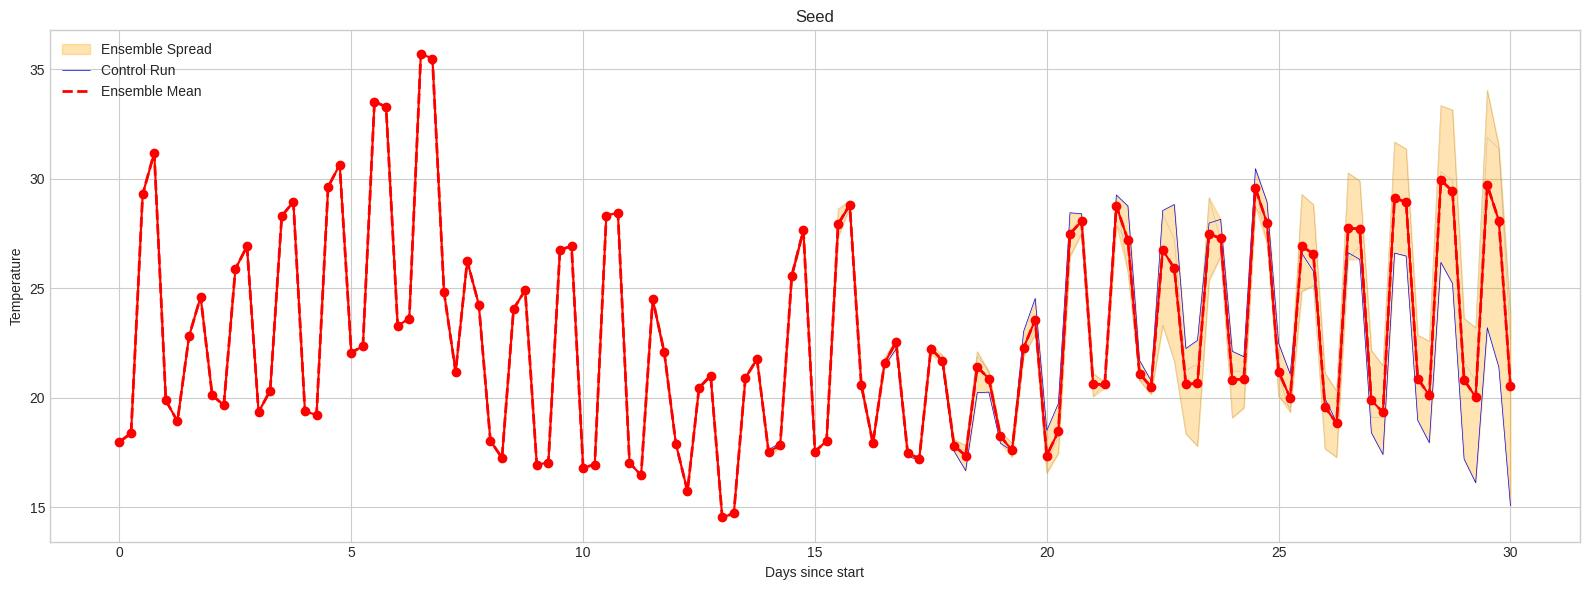

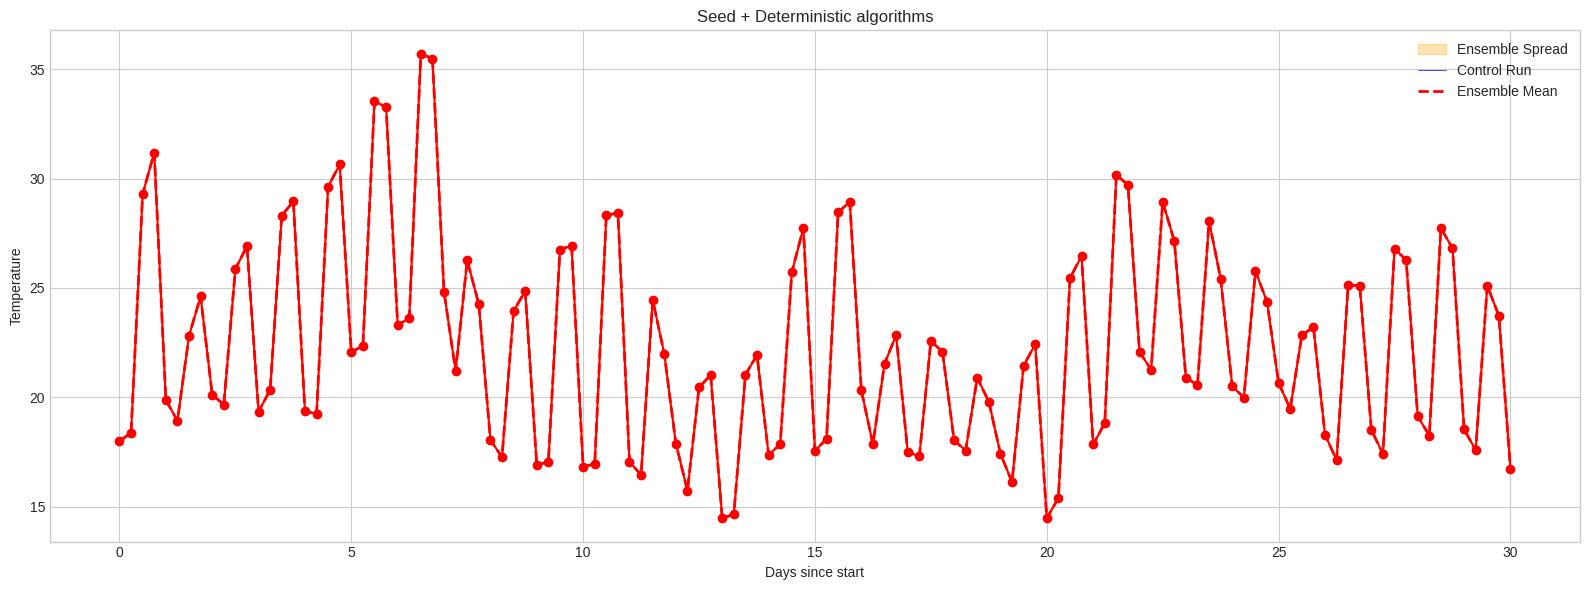

In [5]:
check_chaos(
    (
        reprod_tests_2t_seed.sel(
            latitude=paris_latitude, longitude=paris_longitude, method="nearest"
        )["2t"]
        - 273.15
    ),
    "Seed",
)
check_chaos(
    (
        reprod_tests_2t_seed_deterministic.sel(
            latitude=paris_latitude, longitude=paris_longitude, method="nearest"
        )["2t"]
        - 273.15
    ),
    "Seed + Deterministic algorithms",
)

### Ensemble simulations

In [6]:
dates = ["2021061400", "2025062500"]
variables = ["2t", "z_500", "10u", "10v"]

perturbation_configs = {
    "uniform": {
        "slice": slice(1, 6),
        "exp_name": "test_perturbation_deterministic-uniform",
    },
    "gaussian": {
        "slice": slice(1, 6),
        "exp_name": "test_perturbation_deterministic-gaussian",
    },
    "brownian": {
        "slice": slice(1, 10),
        "exp_name": "test_perturbation_deterministic-brownian",
    },
    "EDA": {"slice": slice(1, 9), "exp_name": "test_perturbation_deterministic-EDA"},
    "CRPS": {"slice": slice(1, 20), "exp_name": "test_crps"},
}

base_dir = "/homedata/pchevali/AIFS_OUTPUTS_REGRIDDED"

datasets_results = {}
chaos_results = {}

for date in dates:
    datasets_results[date] = {var: {} for var in variables}
    chaos_results[date] = {var: {} for var in variables}

    for var in variables:
        for pert_type, config in perturbation_configs.items():
            pattern = f"{base_dir}/{date}-{config['exp_name']}*/*-{var}.nc"
            file_paths = glob.glob(pattern)

            for path in file_paths:
                if pert_type in ["EDA", "CRPS"]:
                    dict_key = pert_type
                else:
                    dict_key = f"{pert_type}-" + path.split(f"{pert_type}-")[
                        -1
                    ].replace(".nc", "")

                ds = fix_lat_lon(xr.open_dataset(path, decode_timedelta=True))

                chaos = EnsembleChaos(
                    control=ds.sel(number=0),
                    perturbed=ds.sel(number=config["slice"]),
                    var_name=var,
                )

                datasets_results[date][var][dict_key] = ds
                chaos_results[date][var][dict_key] = chaos

In [7]:
era5_202106_07 = xr.open_mfdataset(
    [
        "/bdd/ERA5/NETCDF/GLOBAL_025/hourly/AN_SF/2021/t2m.202106.as1e5.GLOBAL_025.nc",
        "/bdd/ERA5/NETCDF/GLOBAL_025/hourly/AN_SF/2021/t2m.202107.as1e5.GLOBAL_025.nc",
    ]
)
era5_202106_07 = era5_202106_07.sel(
    time=era5_202106_07.time.dt.hour.isin([0, 6, 12, 18])
).compute()
mask = (
    era5_202106_07.time >= np.datetime64("2021-06-14T00:00:00.000000000")
).values * (
    era5_202106_07.time <= np.datetime64("2021-07-14T00:00:00.000000000")
).values
era5_202106_07 = fix_lat_lon(era5_202106_07.isel(time=mask))

In [8]:
era5_202506_07 = xr.open_mfdataset(
    [
        "/bdd/ERA5/NETCDF/GLOBAL_025/hourly/AN_SF/2025/t2m.202506.as1e5.GLOBAL_025.nc",
        "/bdd/ERA5/NETCDF/GLOBAL_025/hourly/AN_SF/2025/t2m.202507.as1e5.GLOBAL_025.nc",
    ]
)
era5_202506_07 = era5_202506_07.sel(
    time=era5_202506_07.time.dt.hour.isin([0, 6, 12, 18])
).compute()
mask = (
    era5_202506_07.time >= np.datetime64("2025-06-25T00:00:00.000000000")
).values * (
    era5_202506_07.time <= np.datetime64("2025-07-25T00:00:00.000000000")
).values
era5_202506_07 = fix_lat_lon(era5_202506_07.isel(time=mask))

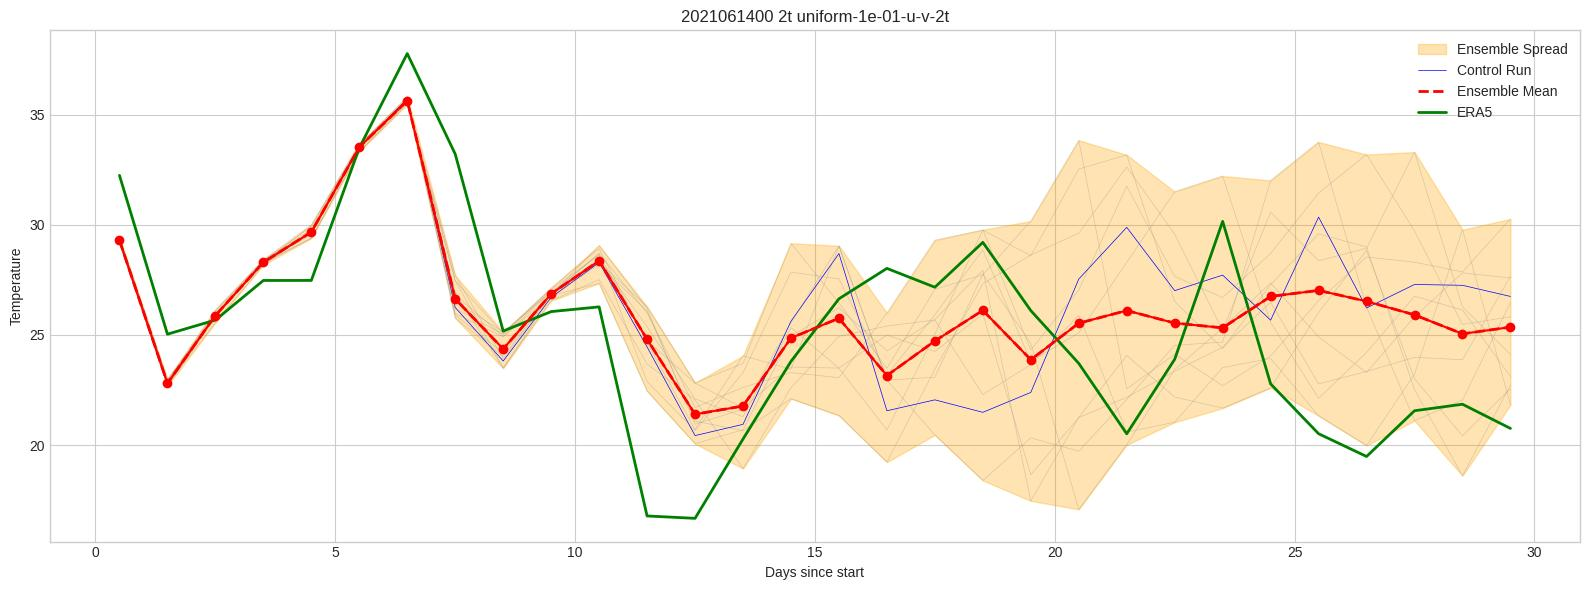

In [9]:
check_chaos(
    datasets_results["2025062500"]["2t"]["brownian-1e-01-u-v-2t"].sel(
        latitude=paris_latitude, longitude=paris_longitude, method="nearest"
    )["2t"]
    - 273.15,
    title="2021061400 2t uniform-1e-01-u-v-2t",
    era=era5_202506_07.sel(
        latitude=paris_latitude, longitude=paris_longitude, method="nearest"
    )["t2m"]
    - 273.15,
    time_of_day=[12],
)

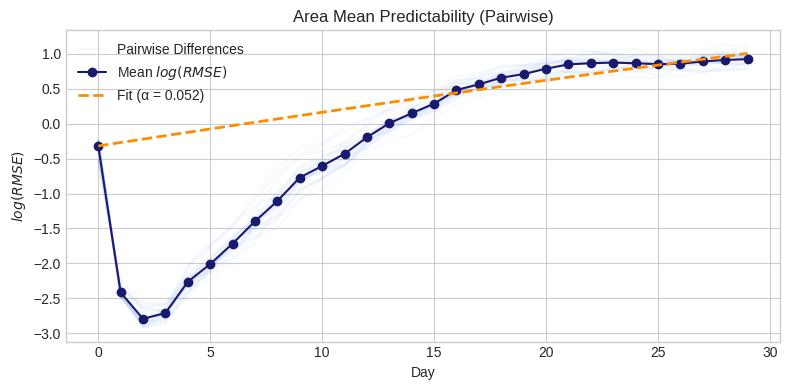

Estimated Growth Rate (α): 0.052 days^-1 | Saturation Error (E_inf): 12.644


(np.float64(0.052), np.float64(12.644))

In [10]:
chaos_results["2021061400"]["2t"]["uniform-1e-01-2t-2t"].growth_rate_pairwise(
    lat=northern_hemisphere_latitude_bnd,
    lon=northern_hemisphere_longitude_bnd,
    times=[12],
)

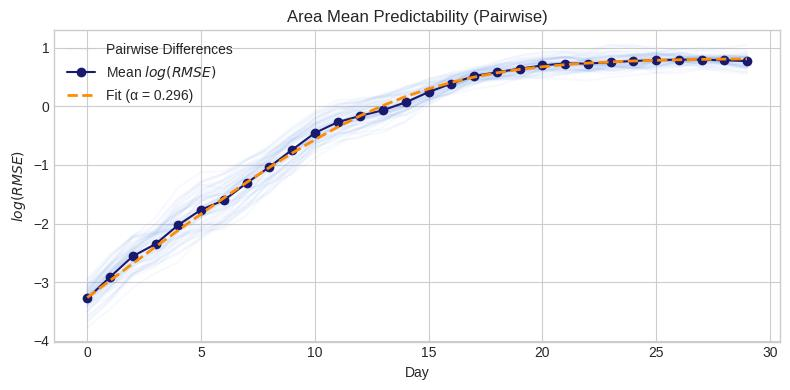

Estimated Growth Rate (α): 0.296 days^-1 | Saturation Error (E_inf): 2.267


(np.float64(0.296), np.float64(2.267))

In [11]:
chaos_results["2025062500"]["2t"]["brownian-1e-01-u-v-2t"].growth_rate_pairwise(
    northern_hemisphere_latitude_bnd, northern_hemisphere_longitude_bnd, times=[12]
)

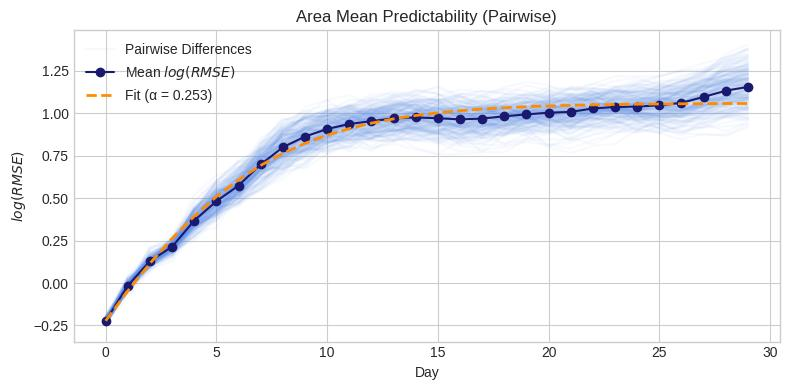

Estimated Growth Rate (α): 0.253 days^-1 | Saturation Error (E_inf): 2.882


(np.float64(0.253), np.float64(2.882))

In [12]:
chaos_results["2025062500"]["2t"]["CRPS"].growth_rate_pairwise(
    northern_hemisphere_latitude_bnd, northern_hemisphere_longitude_bnd, times=[12]
)

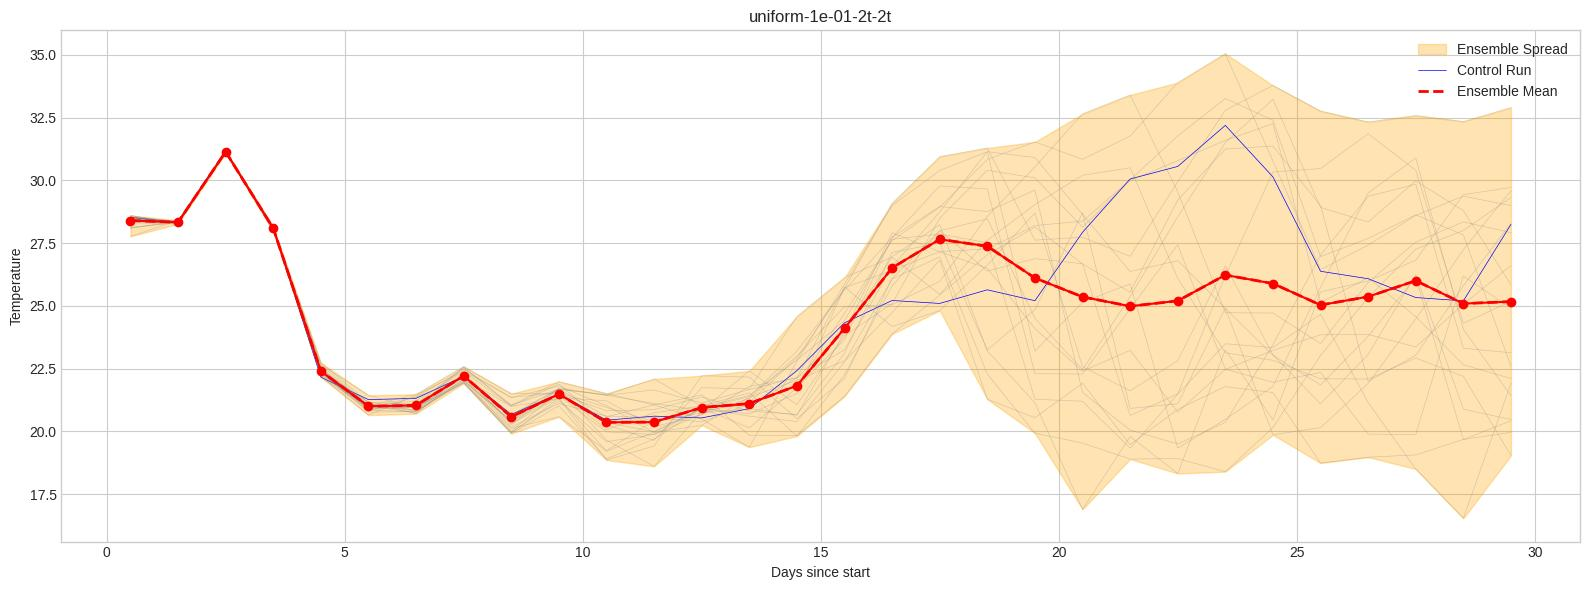

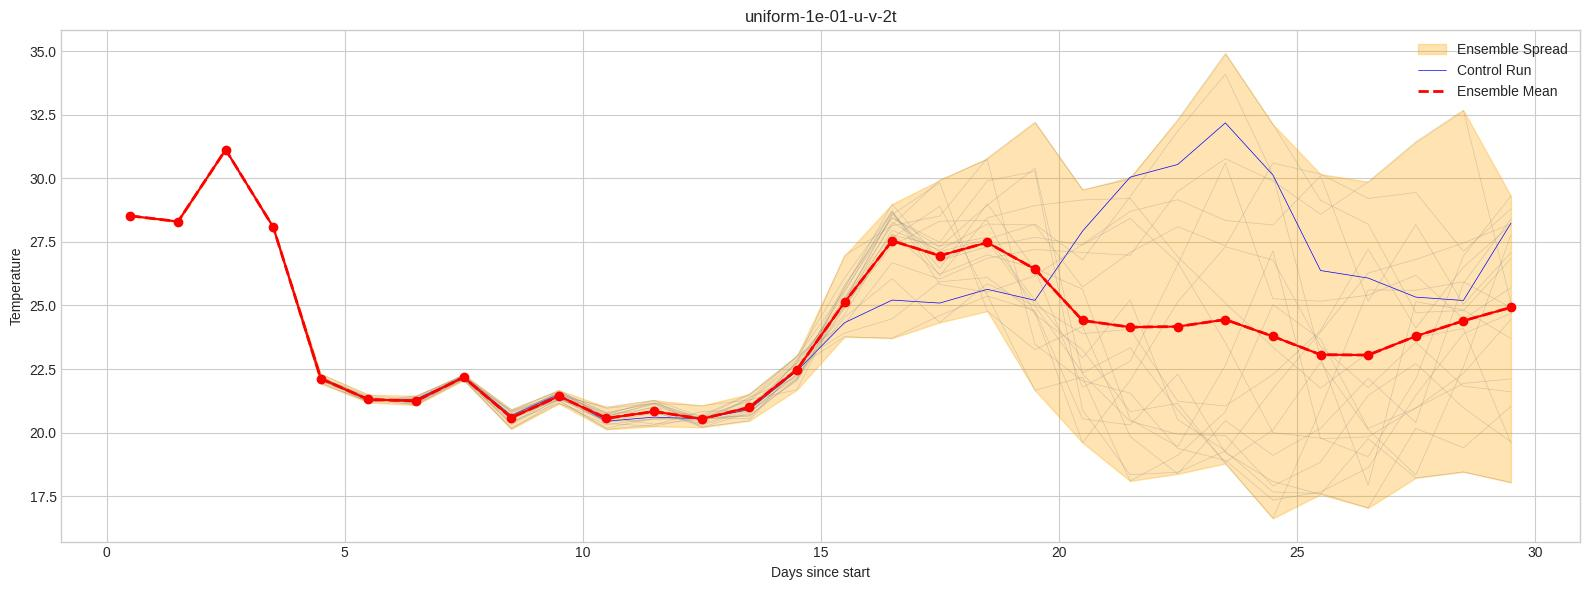

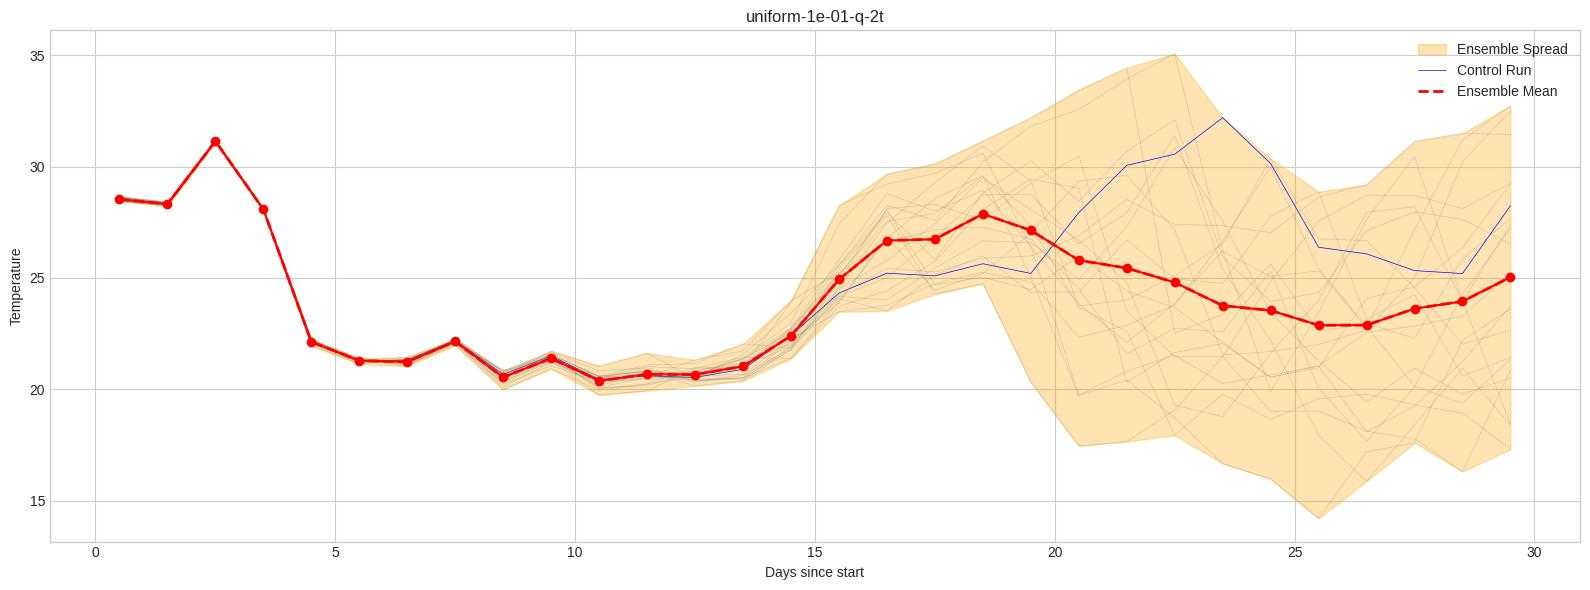

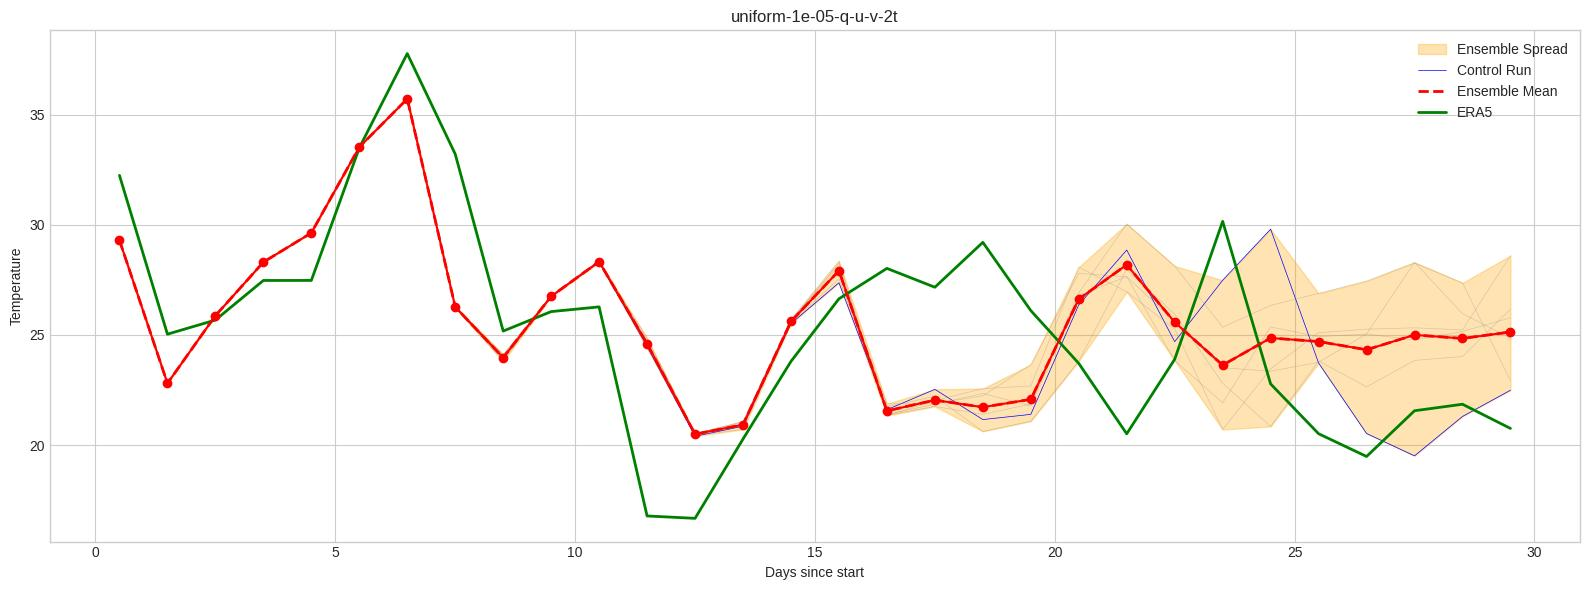

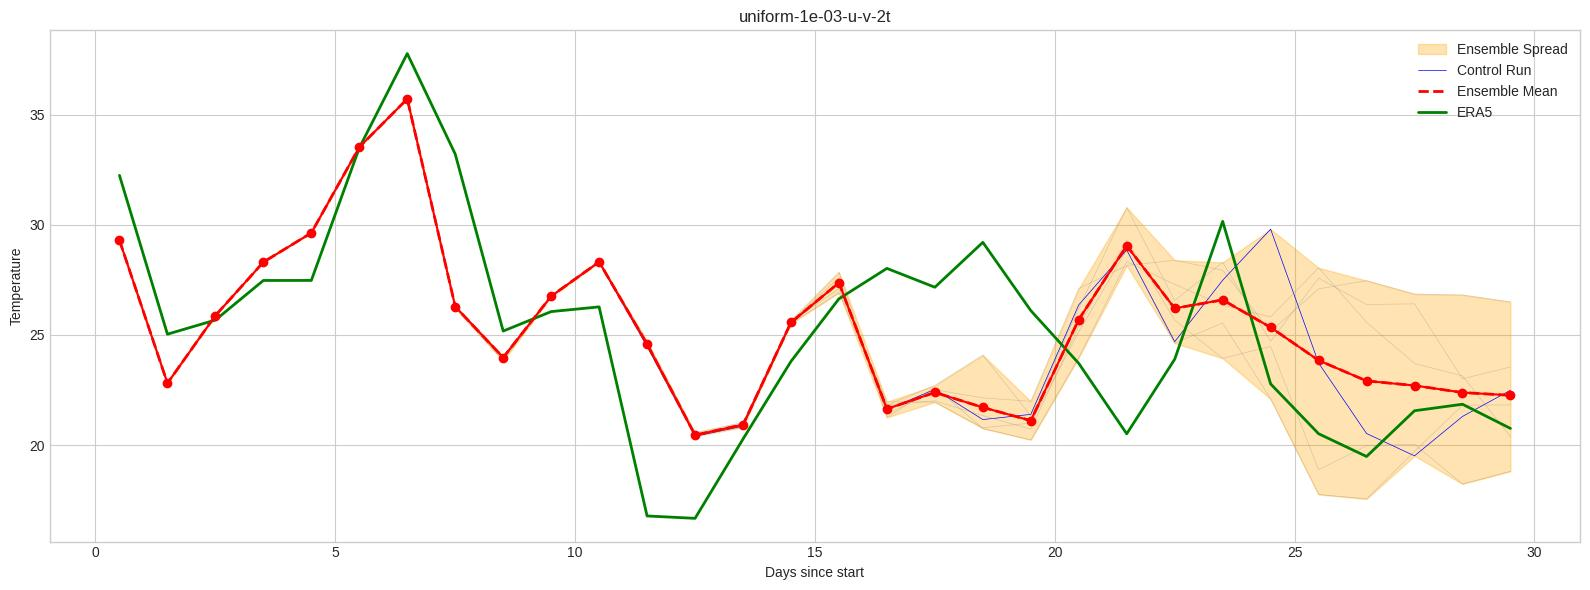

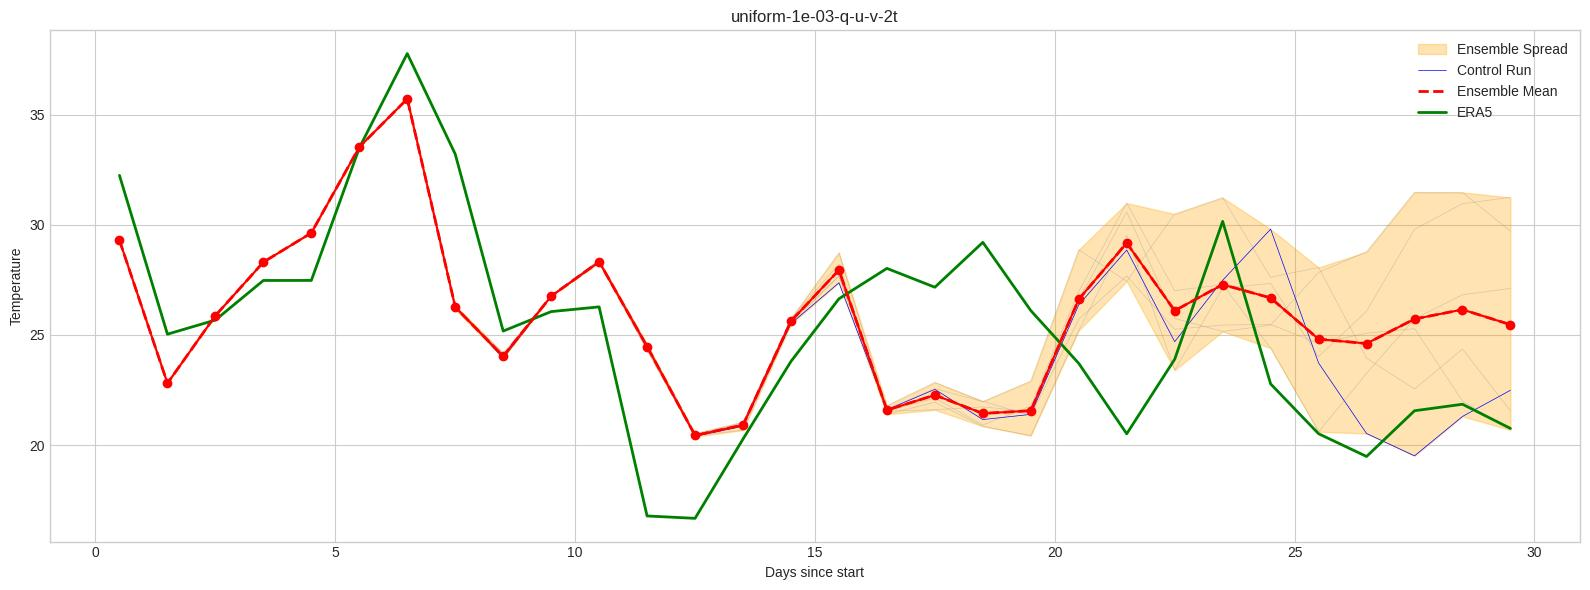

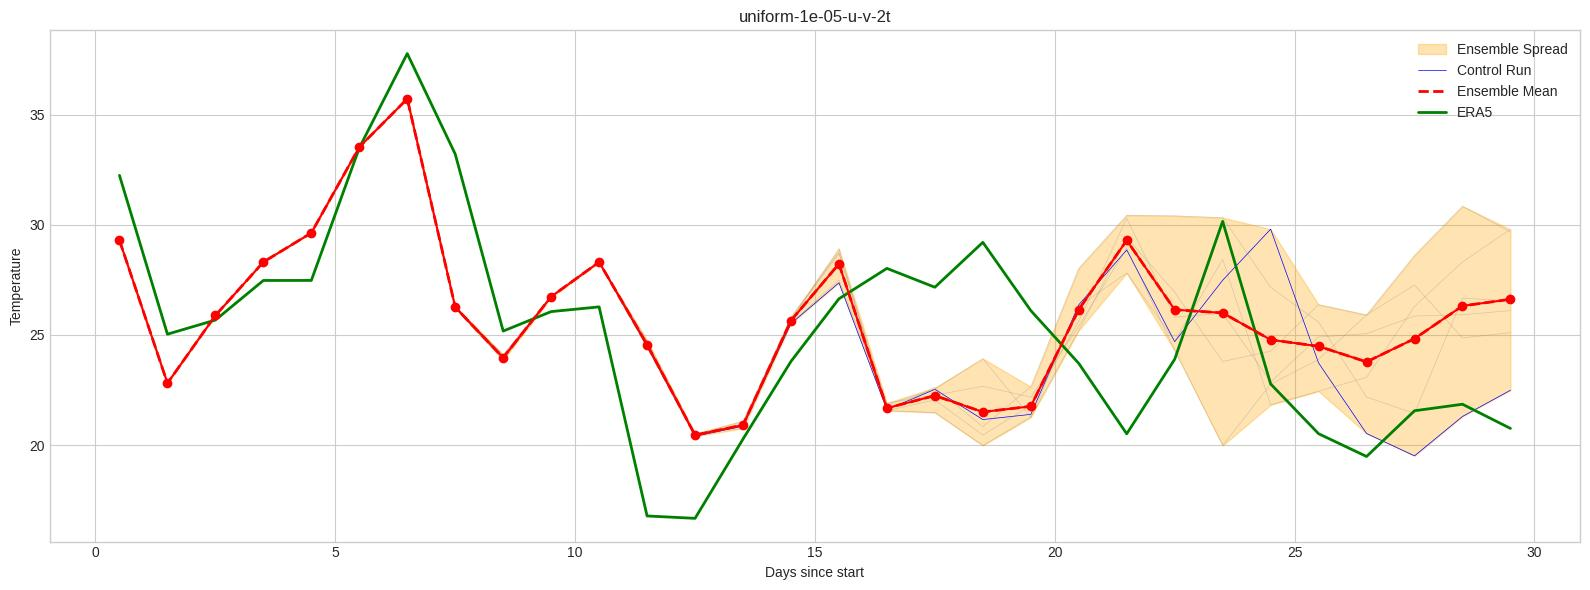

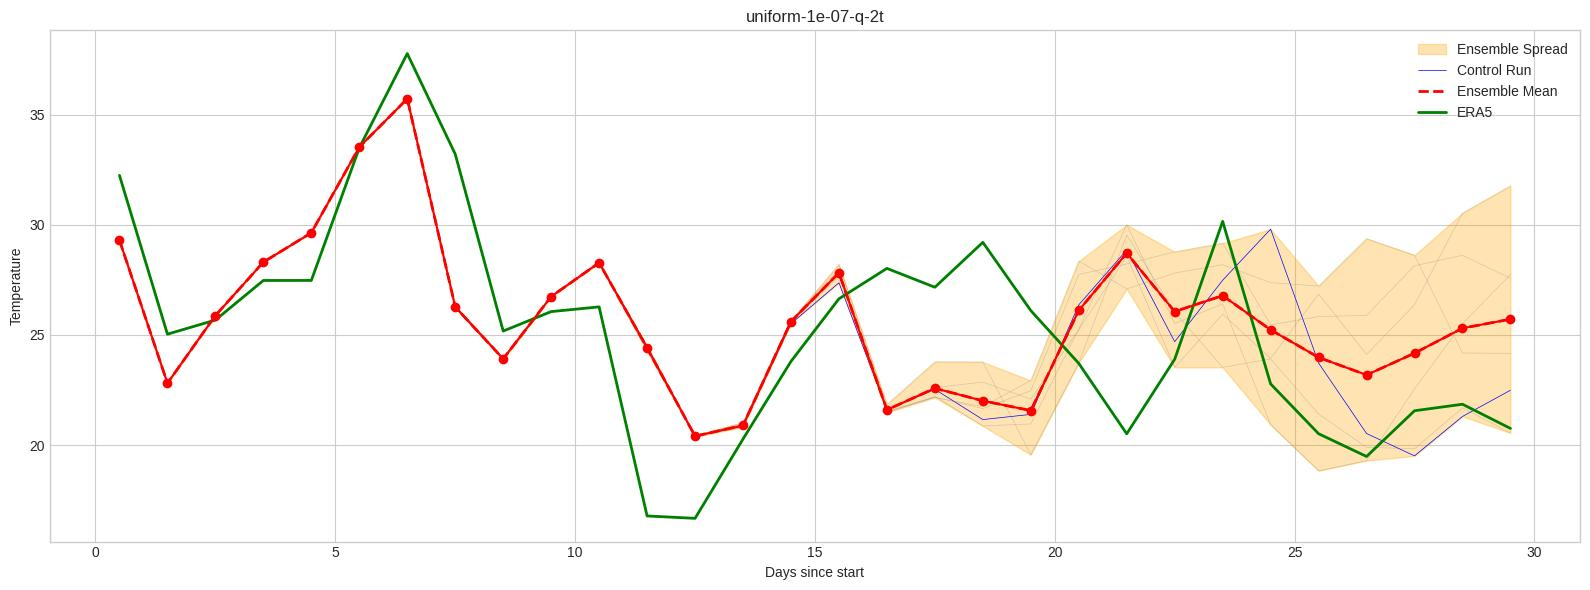

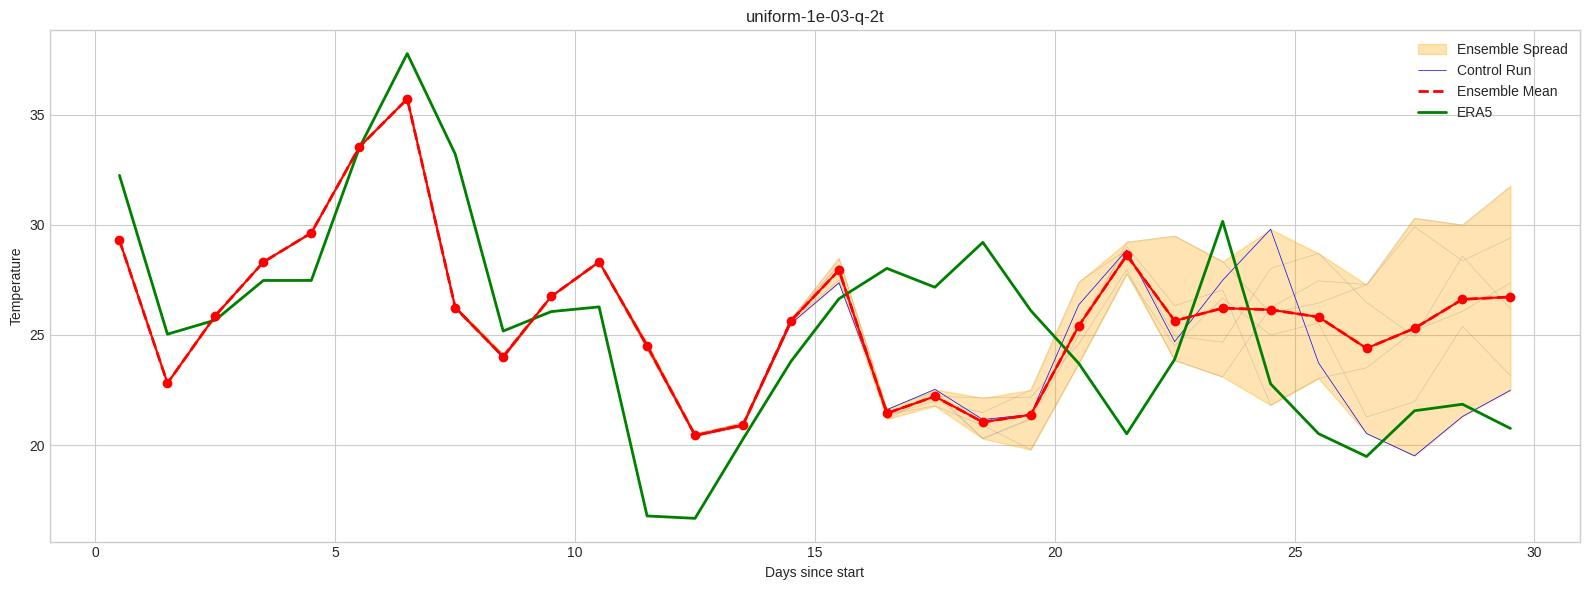

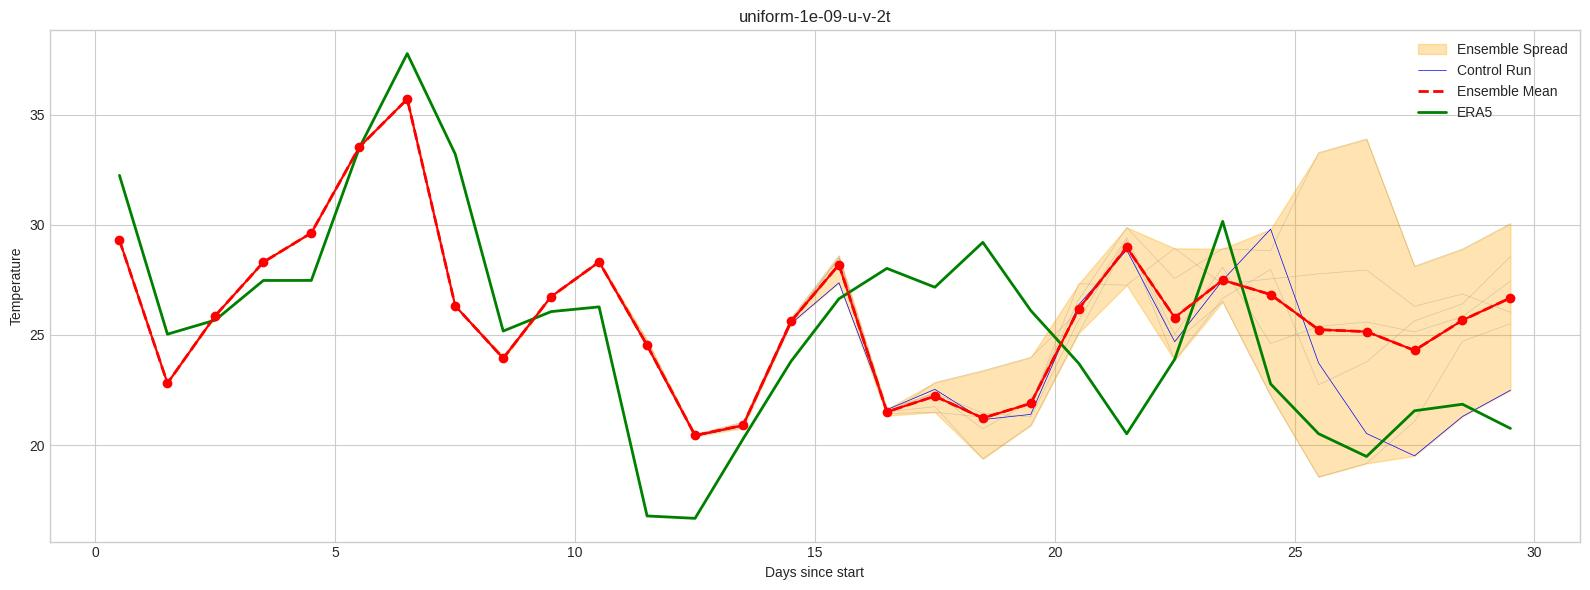

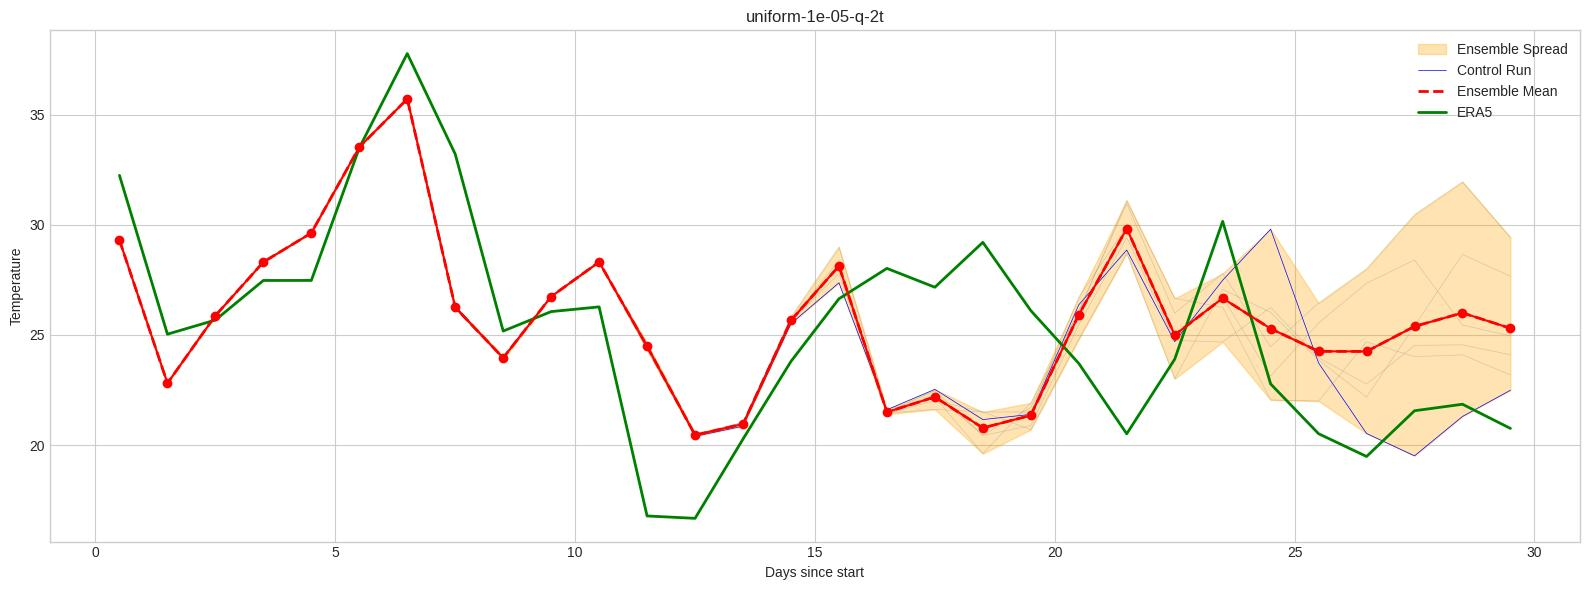

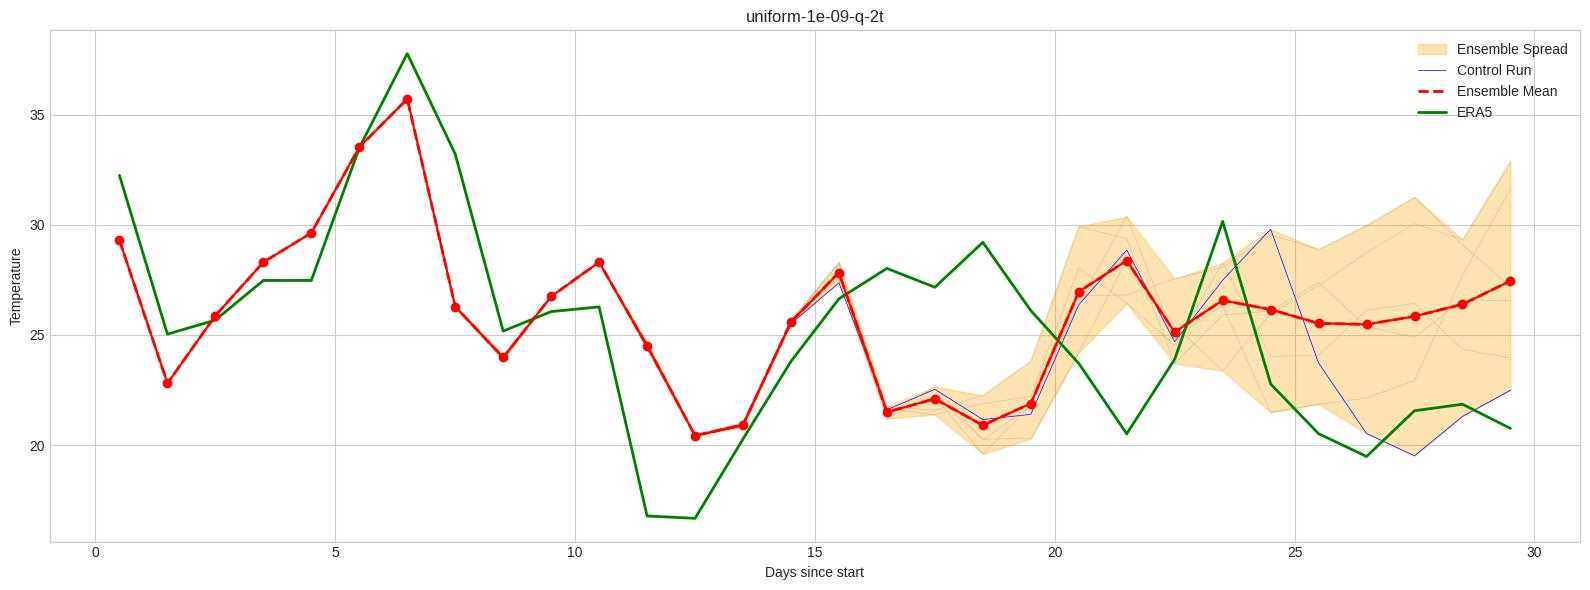

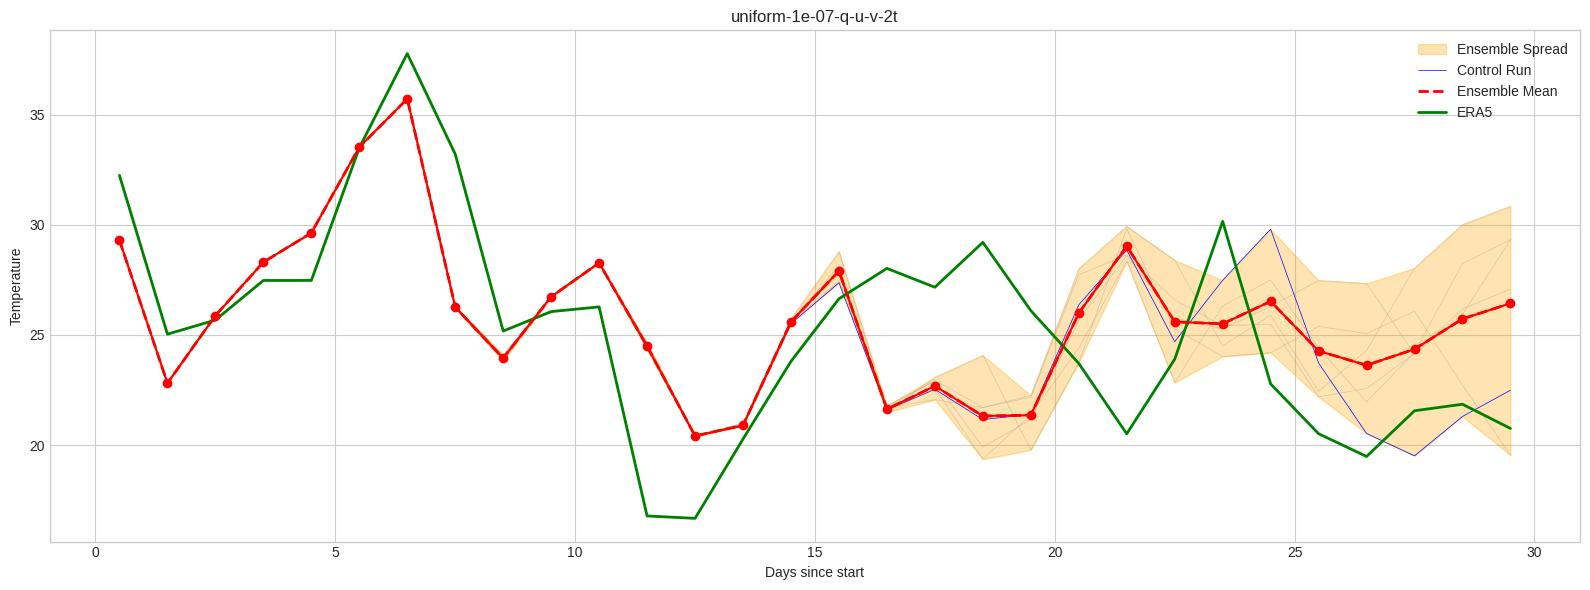

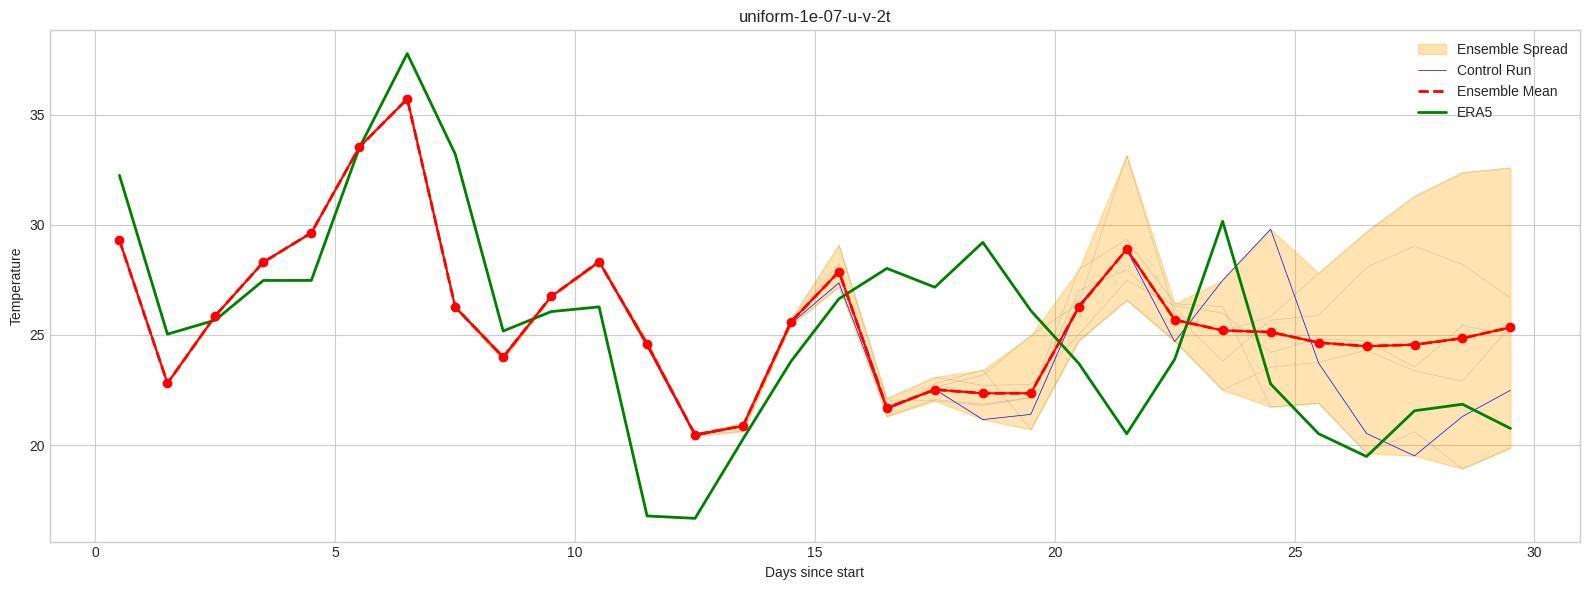

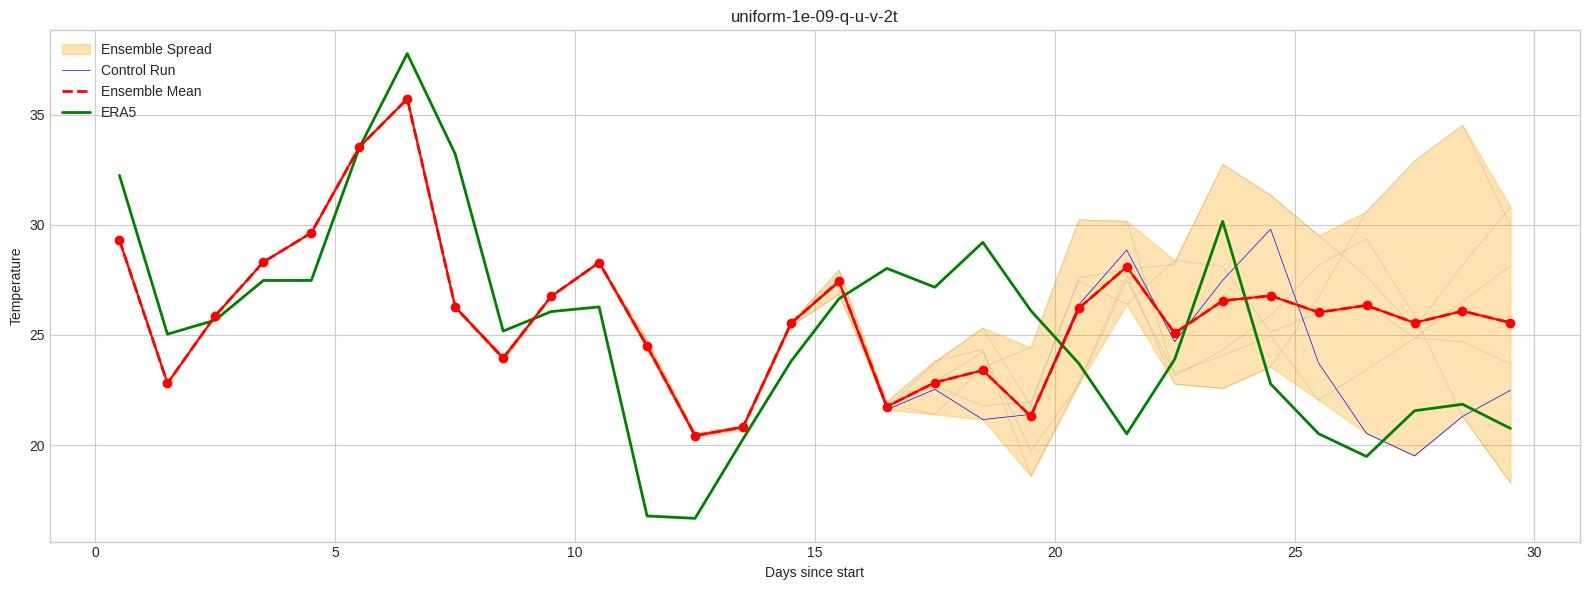

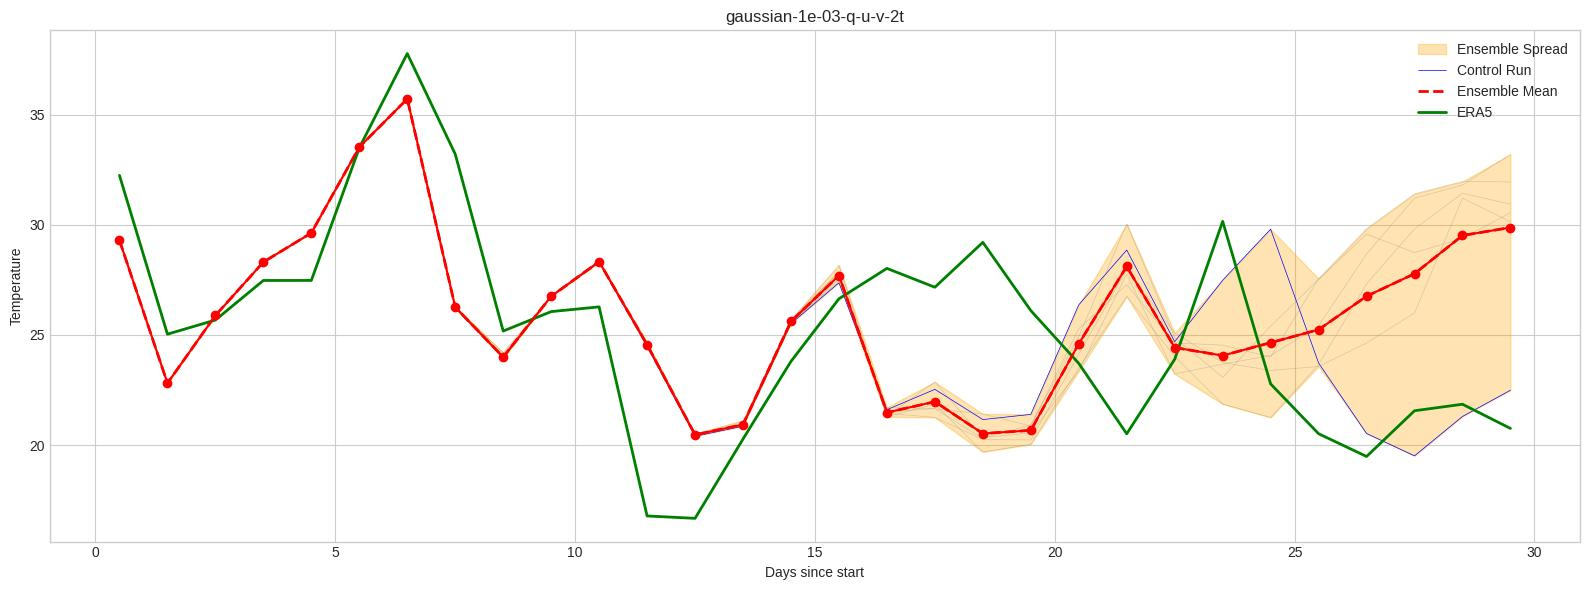

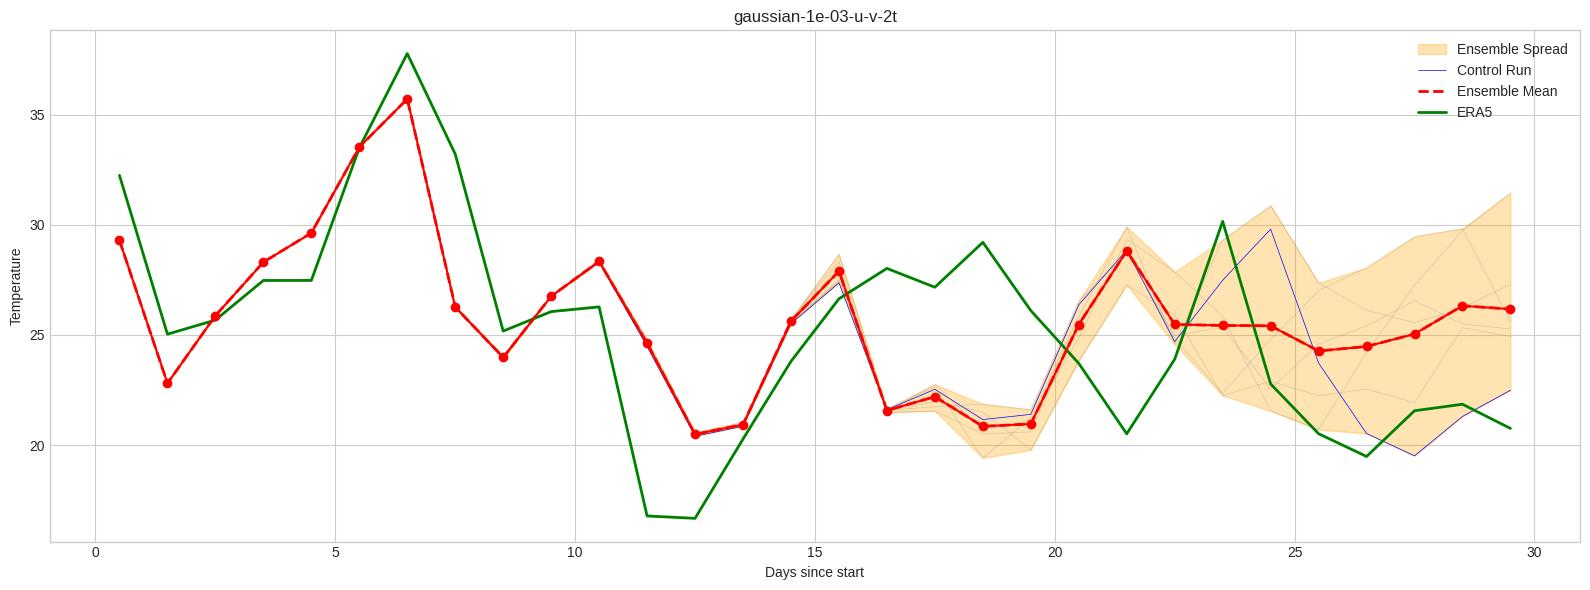

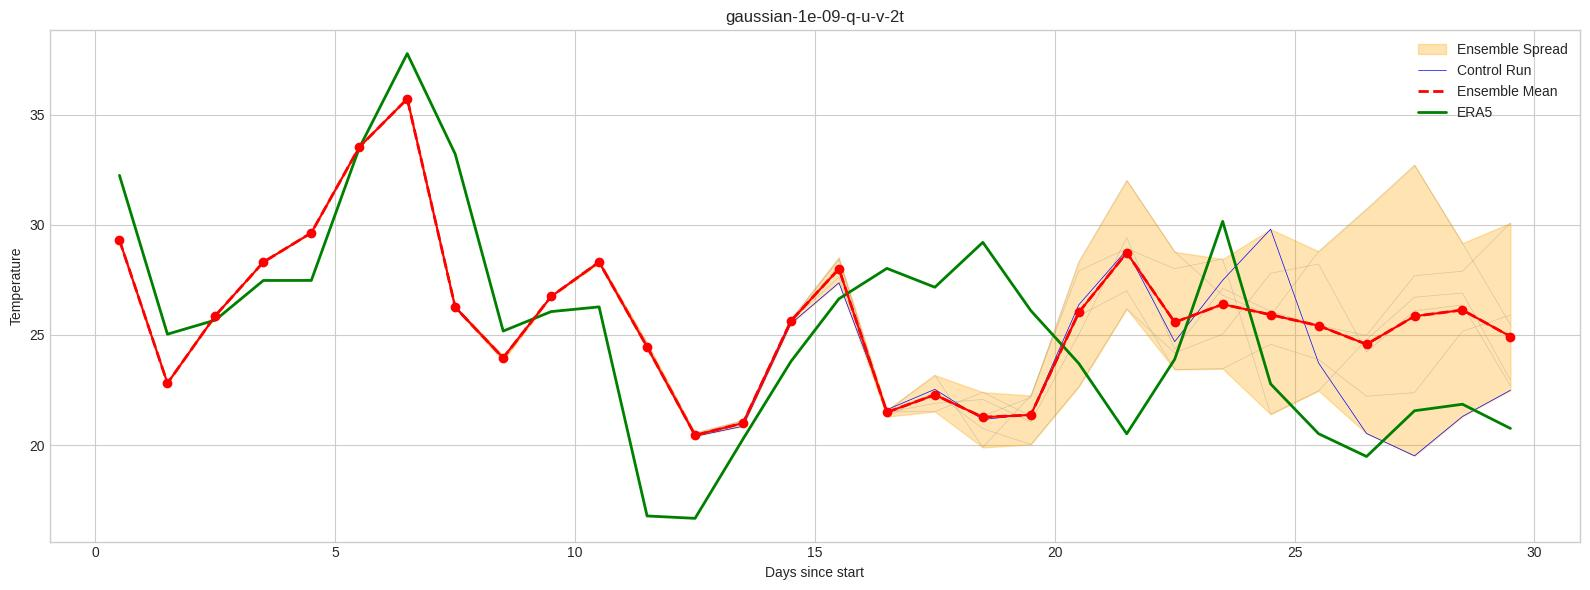

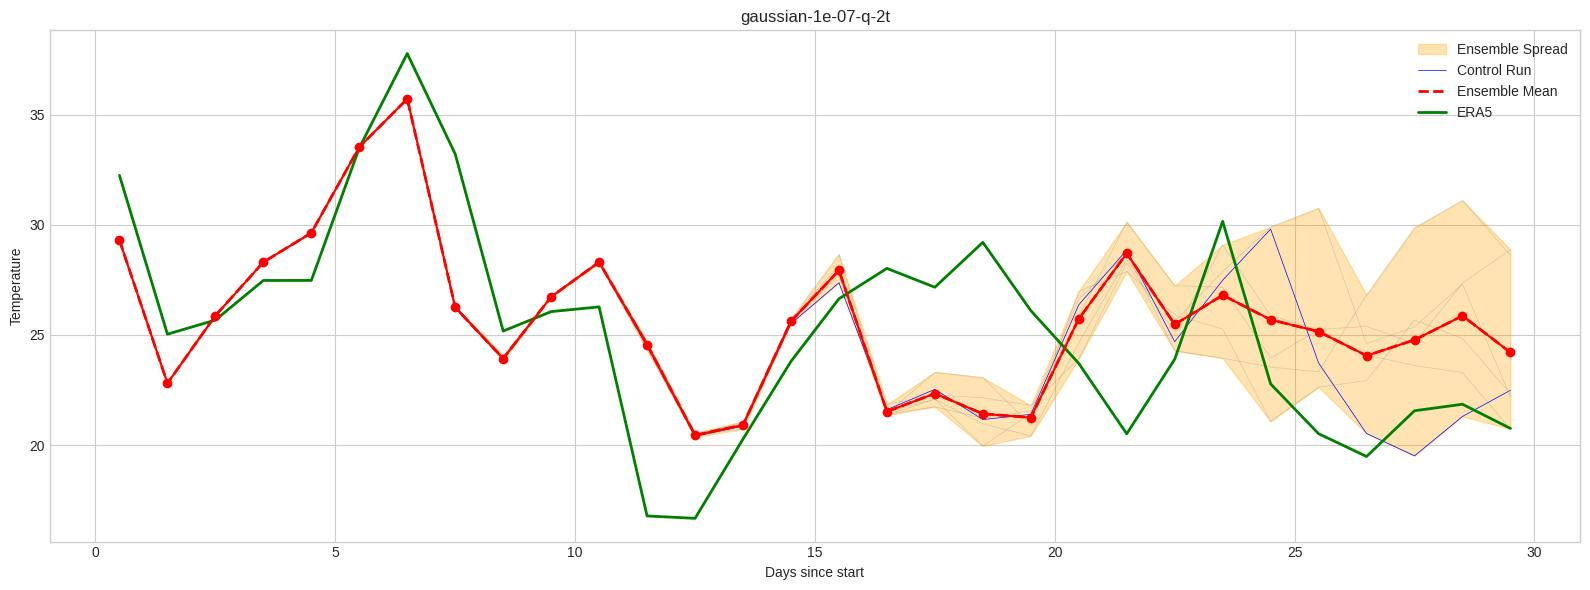

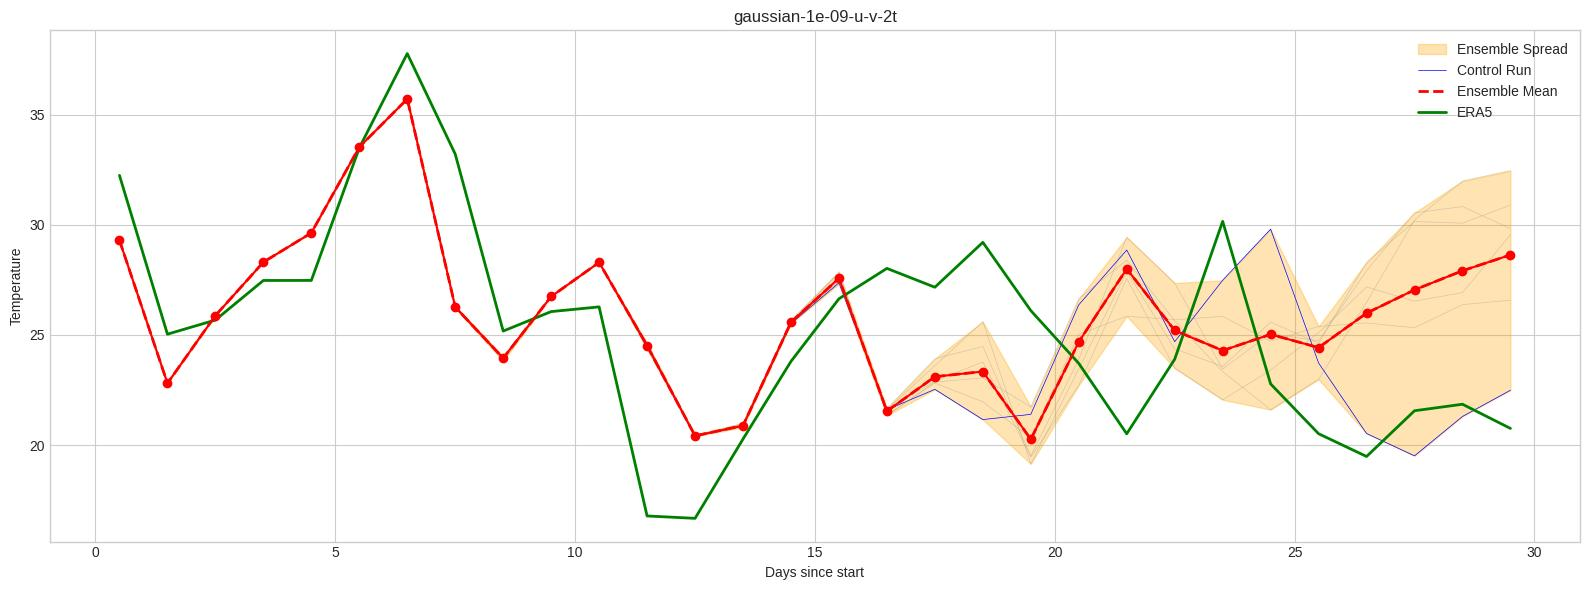

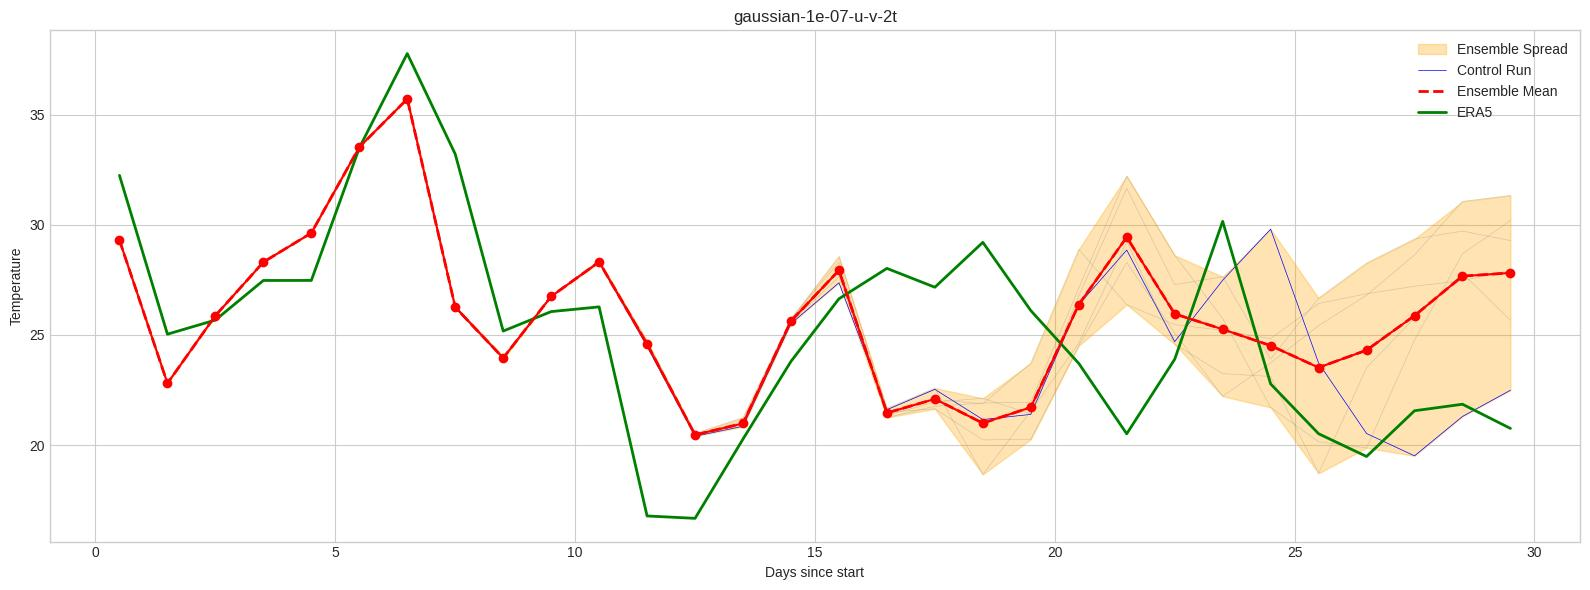

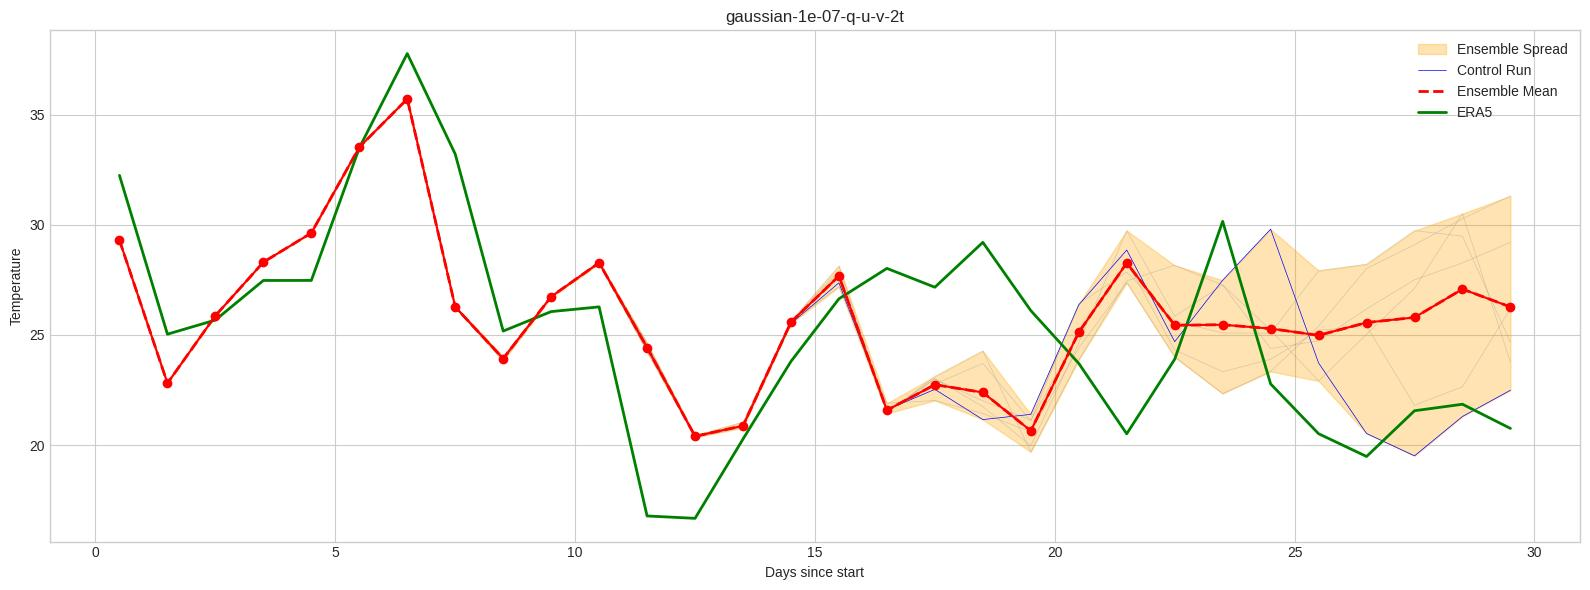

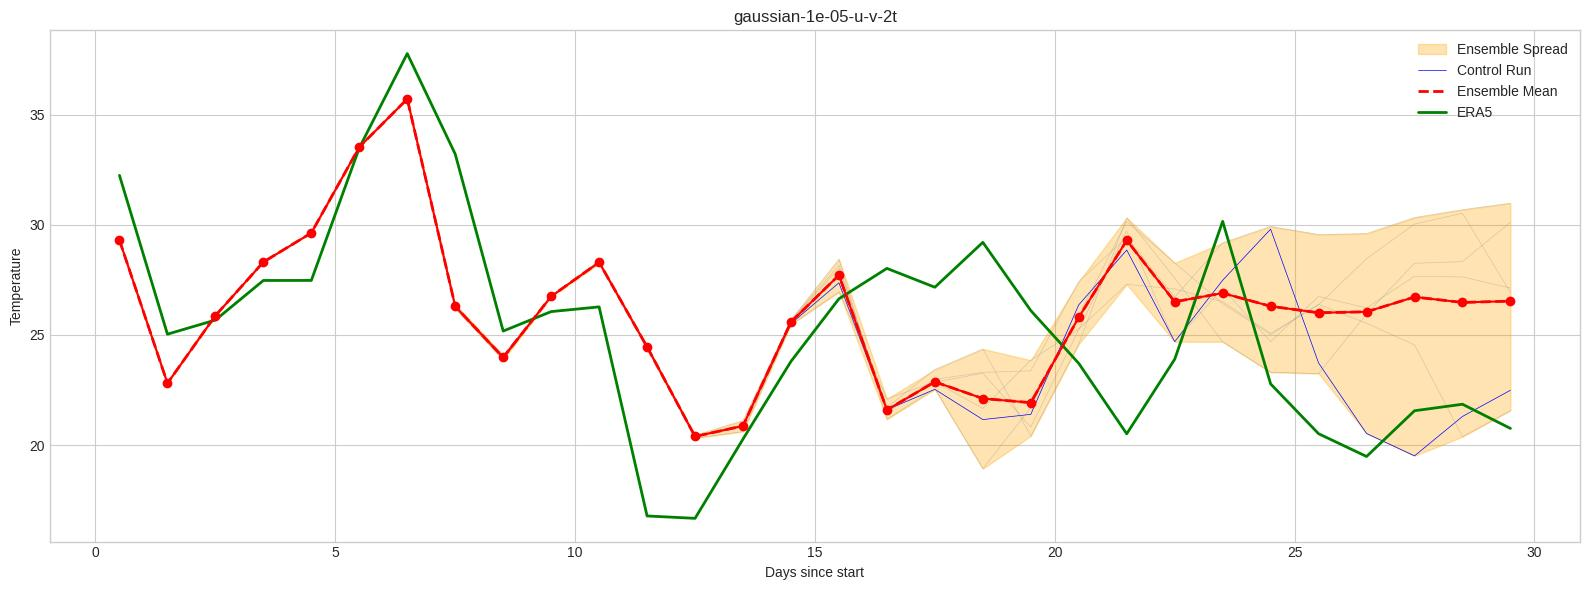

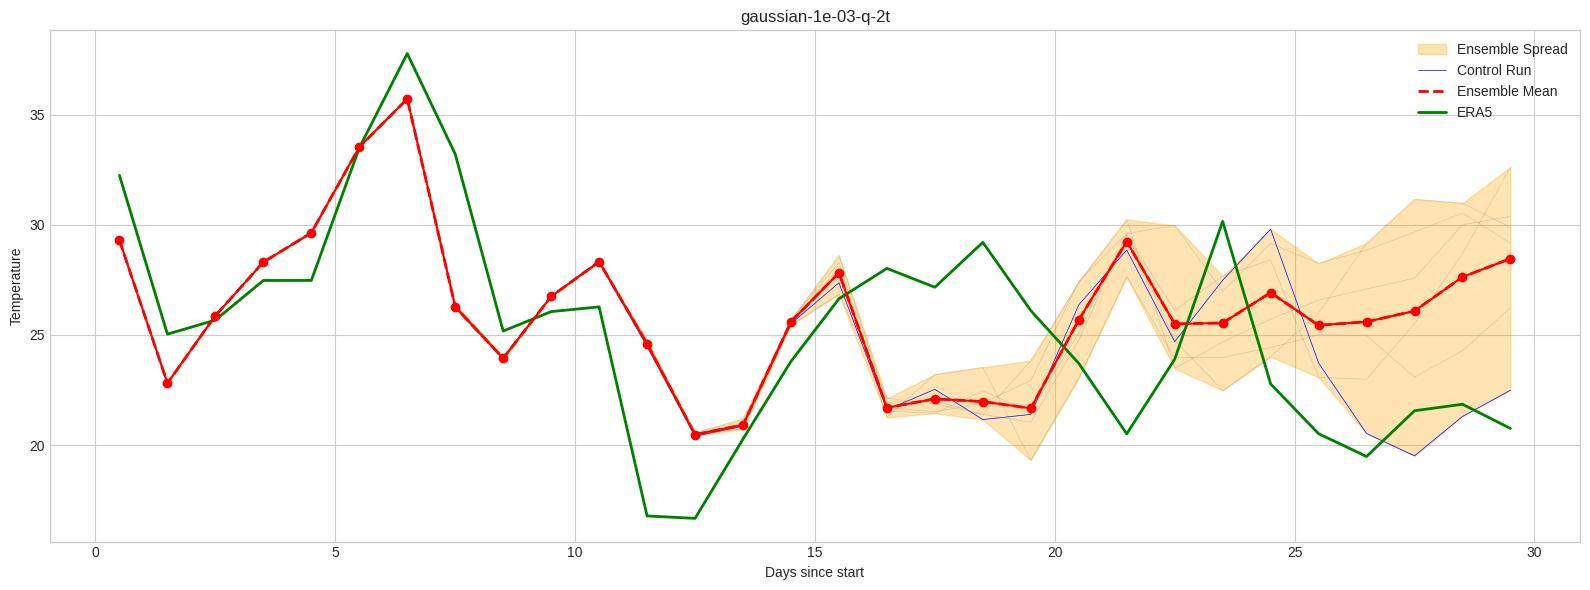

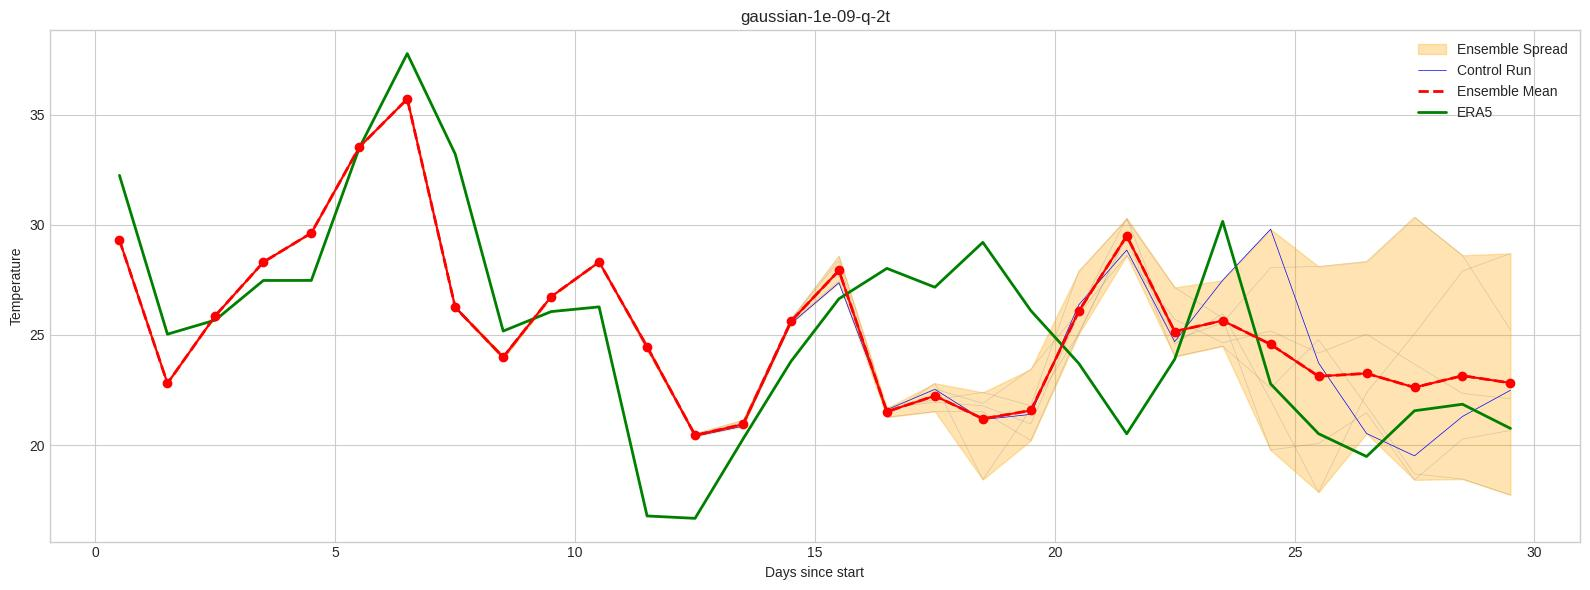

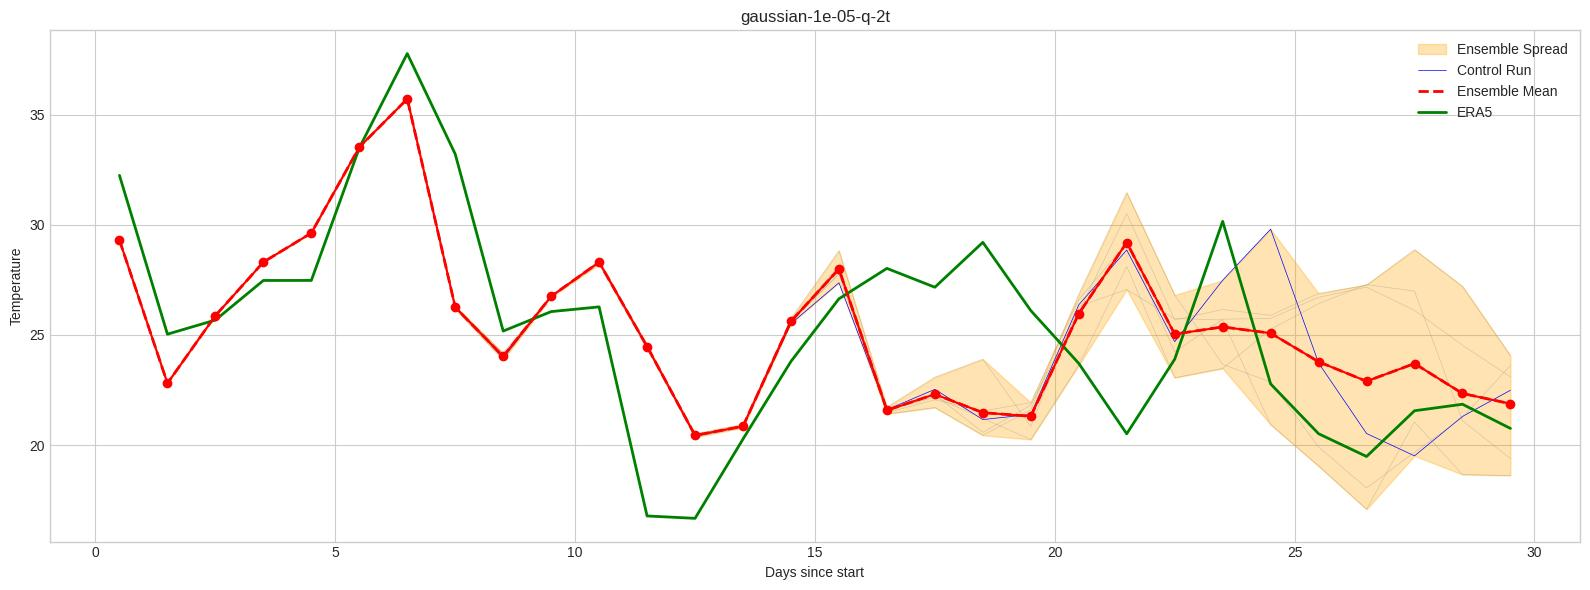

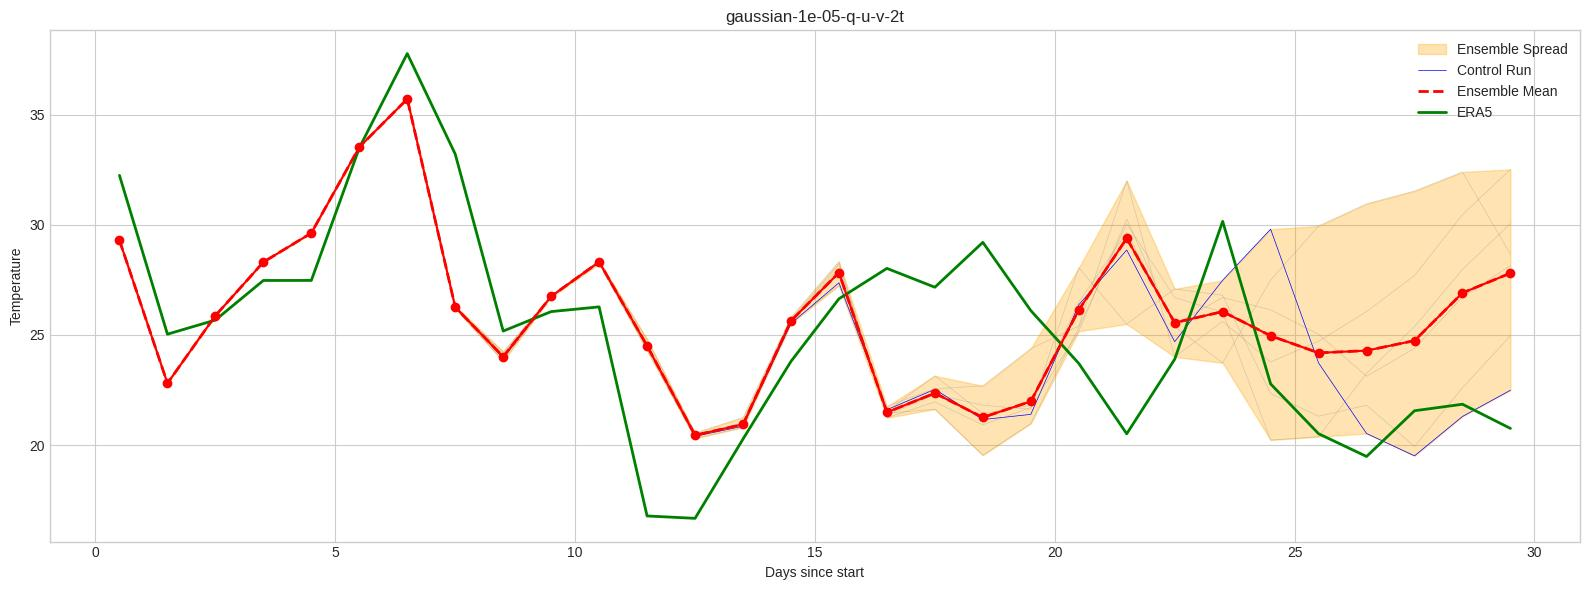

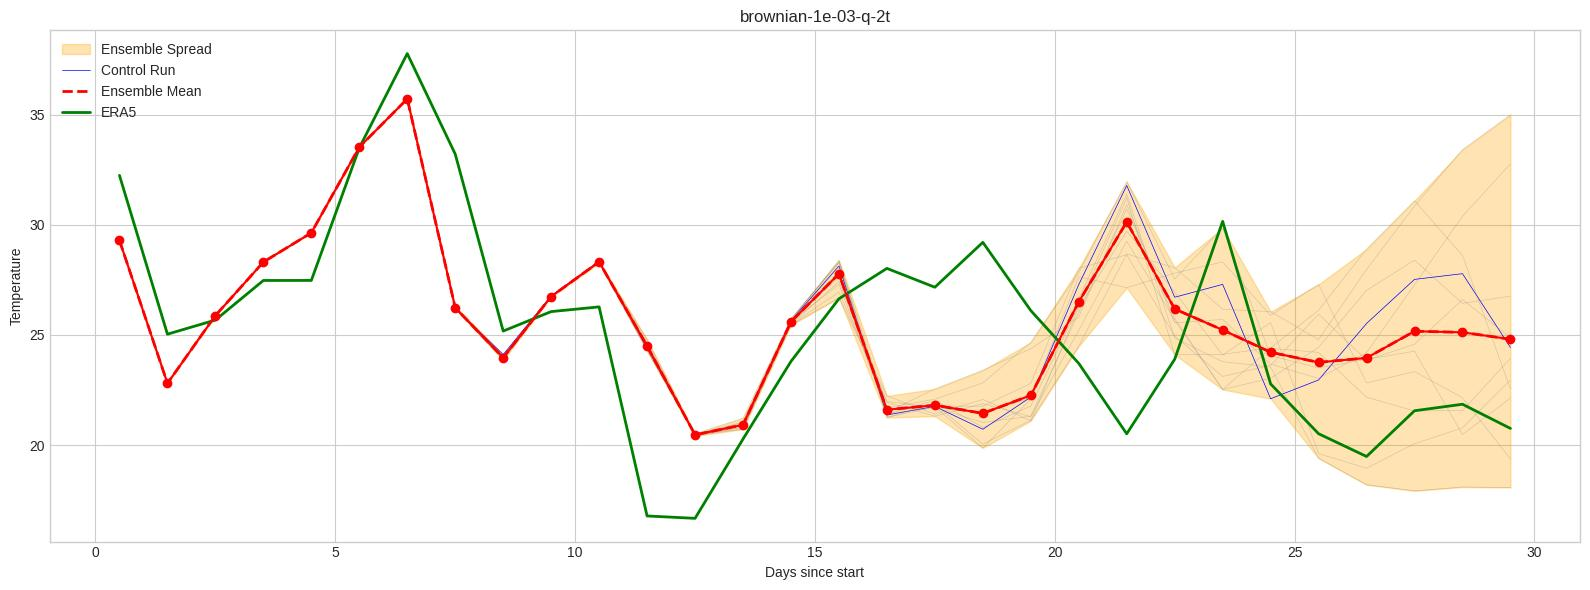

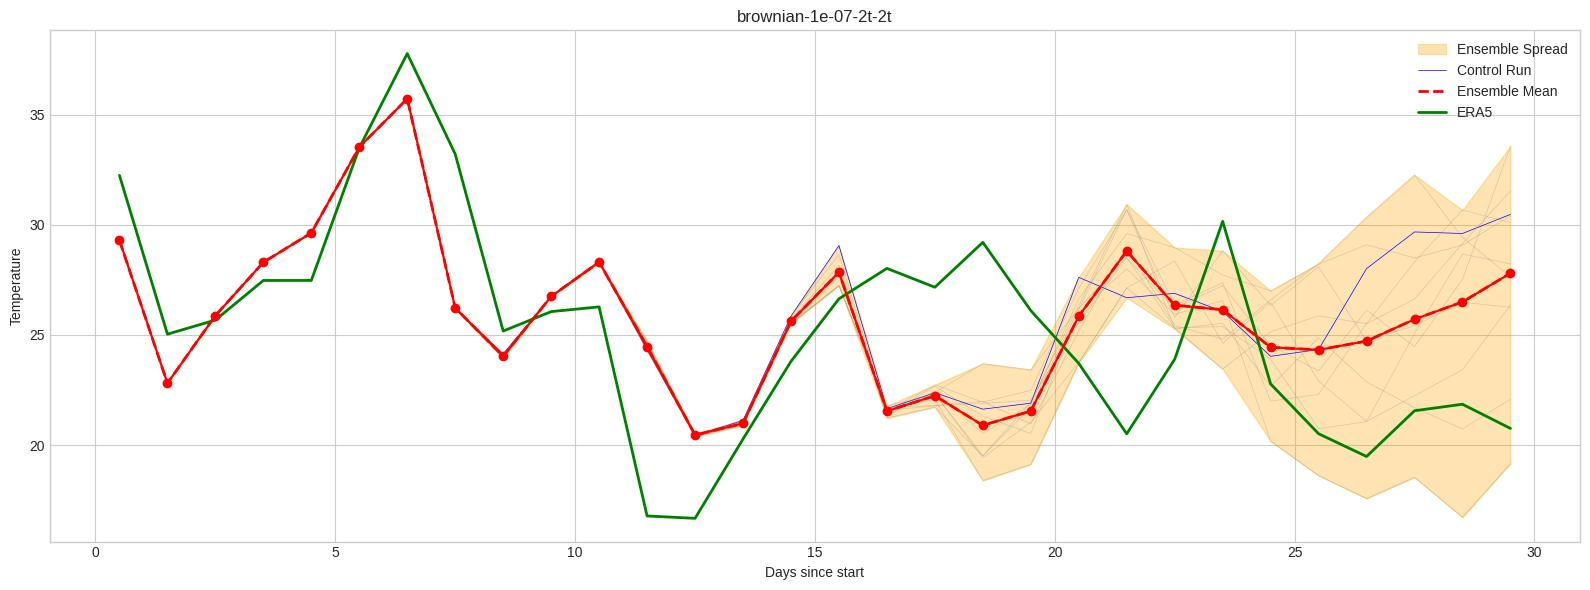

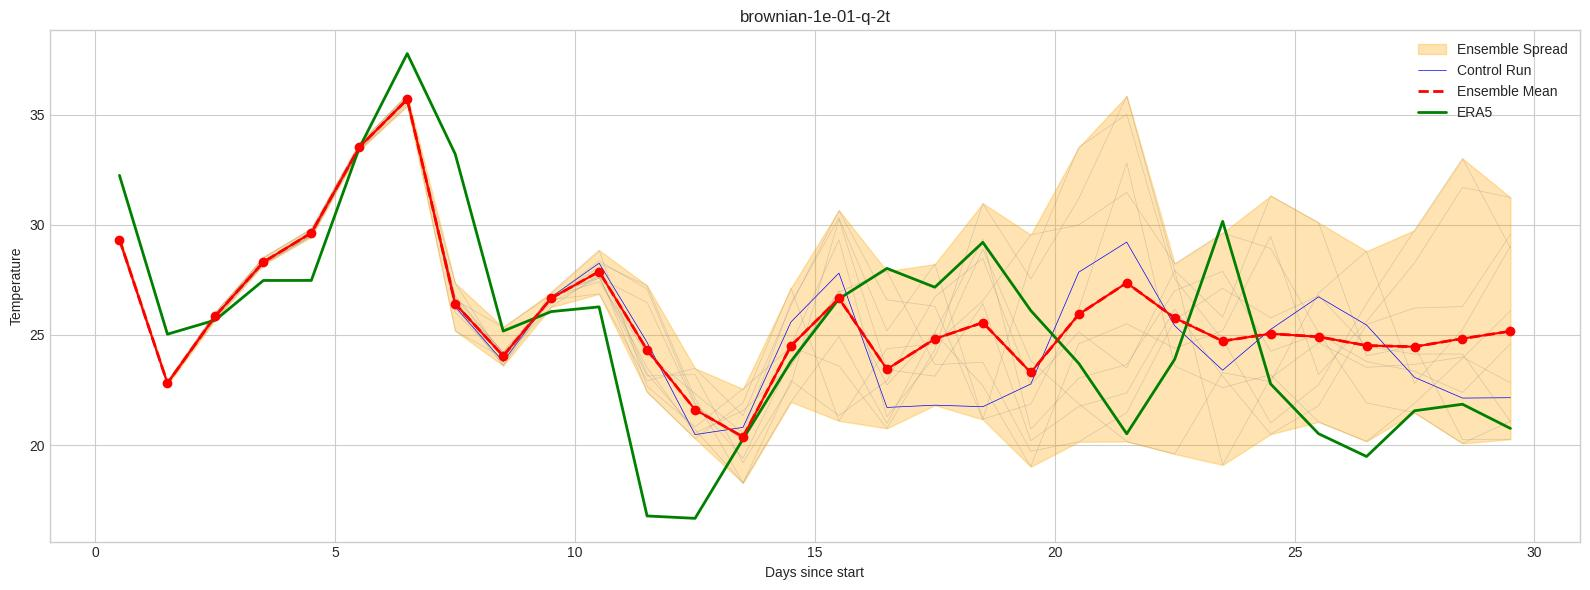

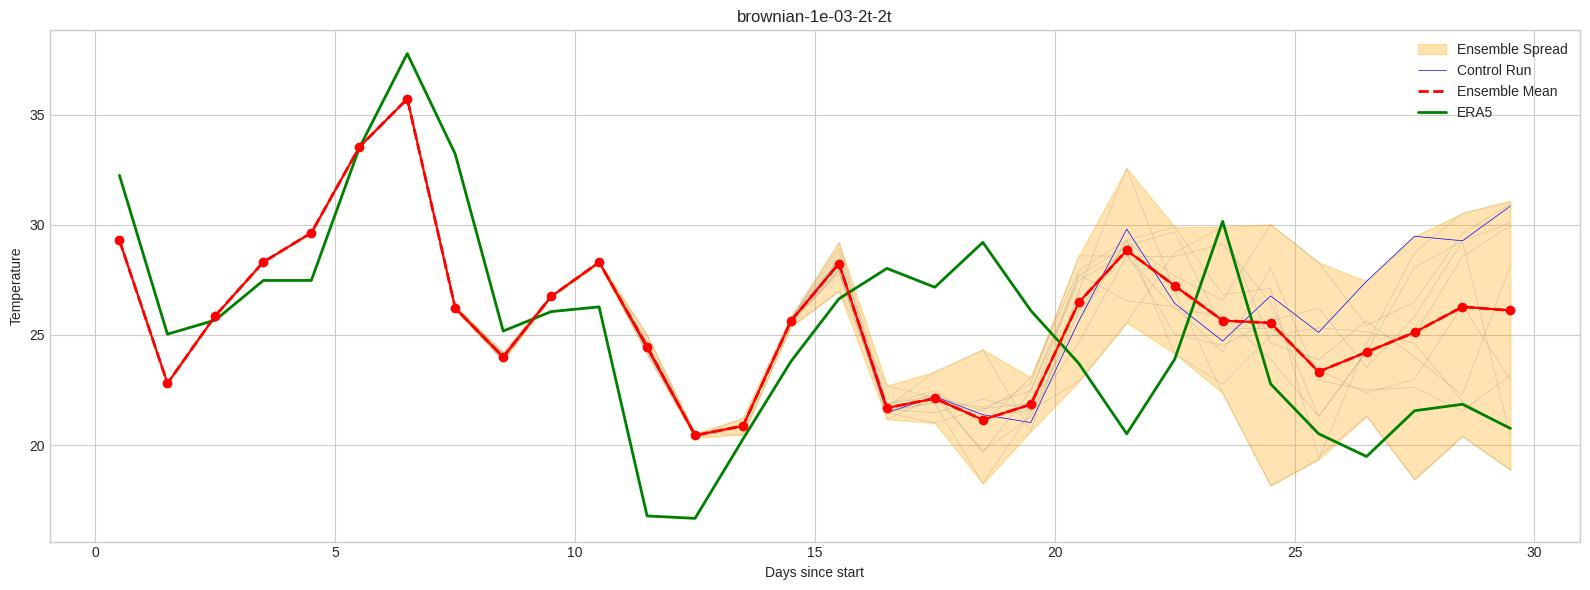

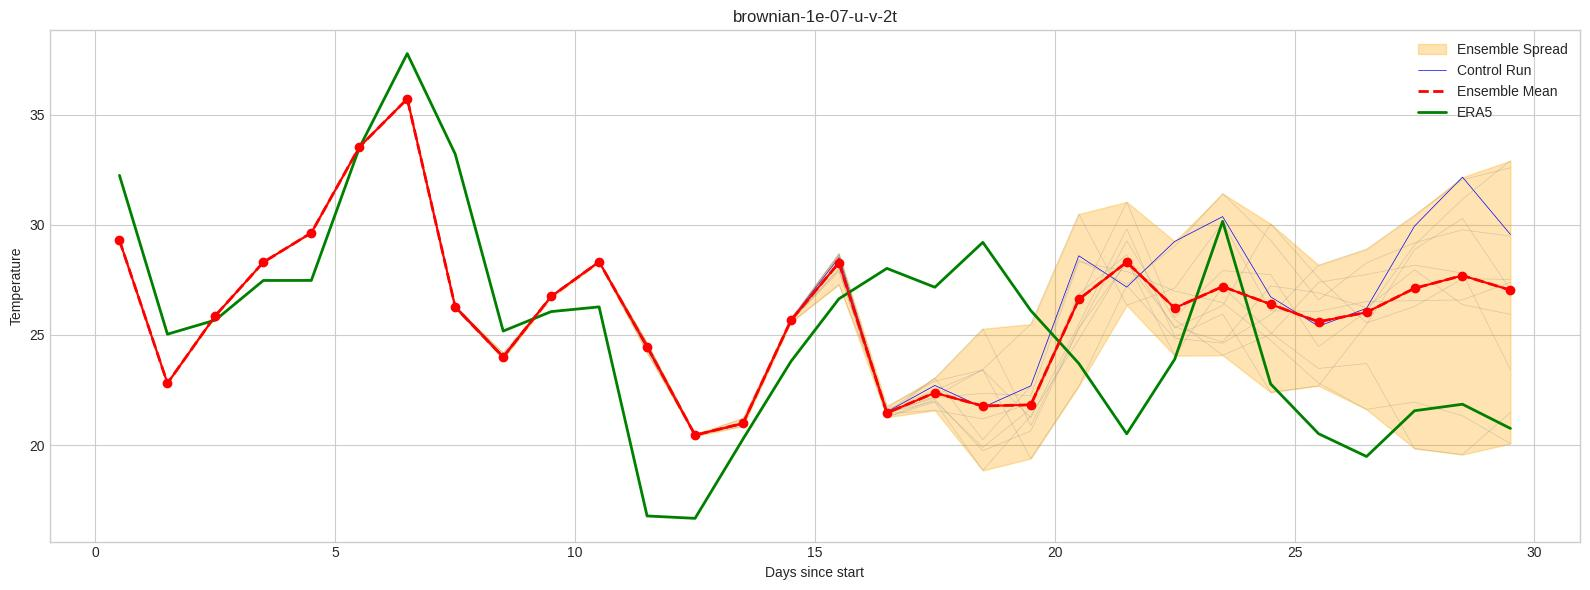

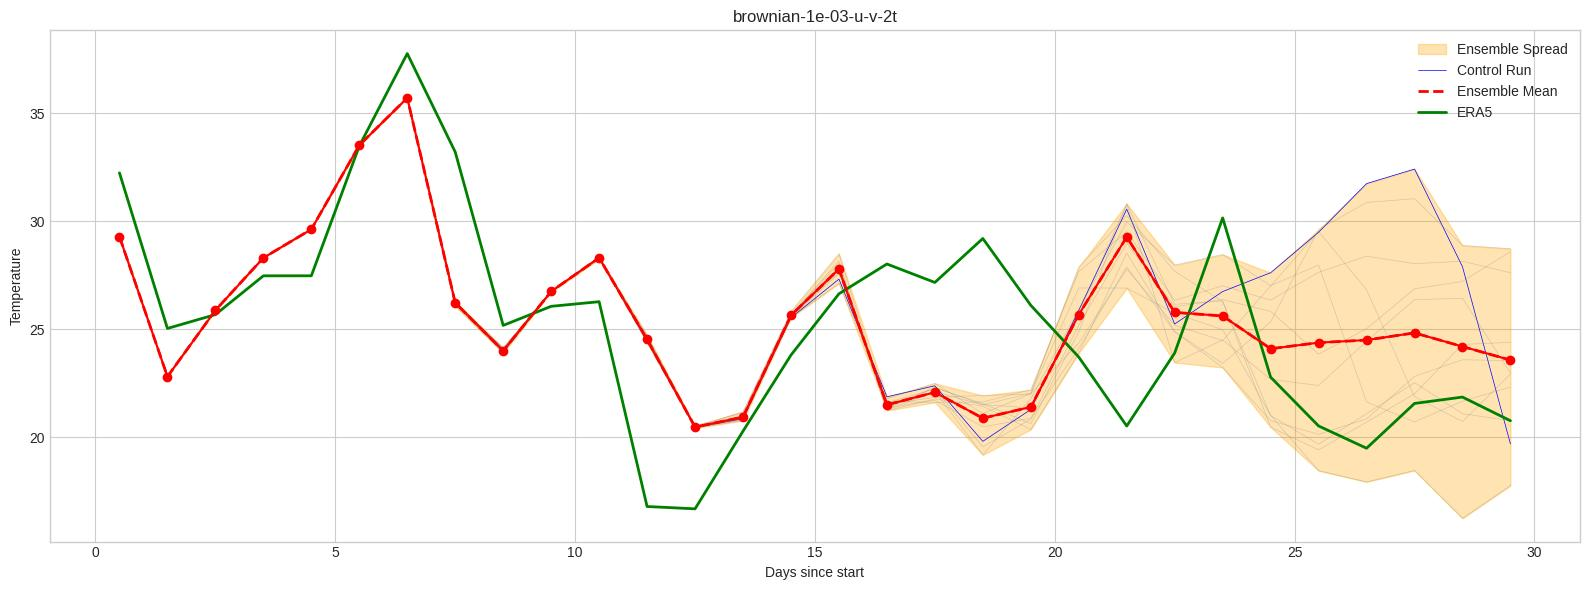

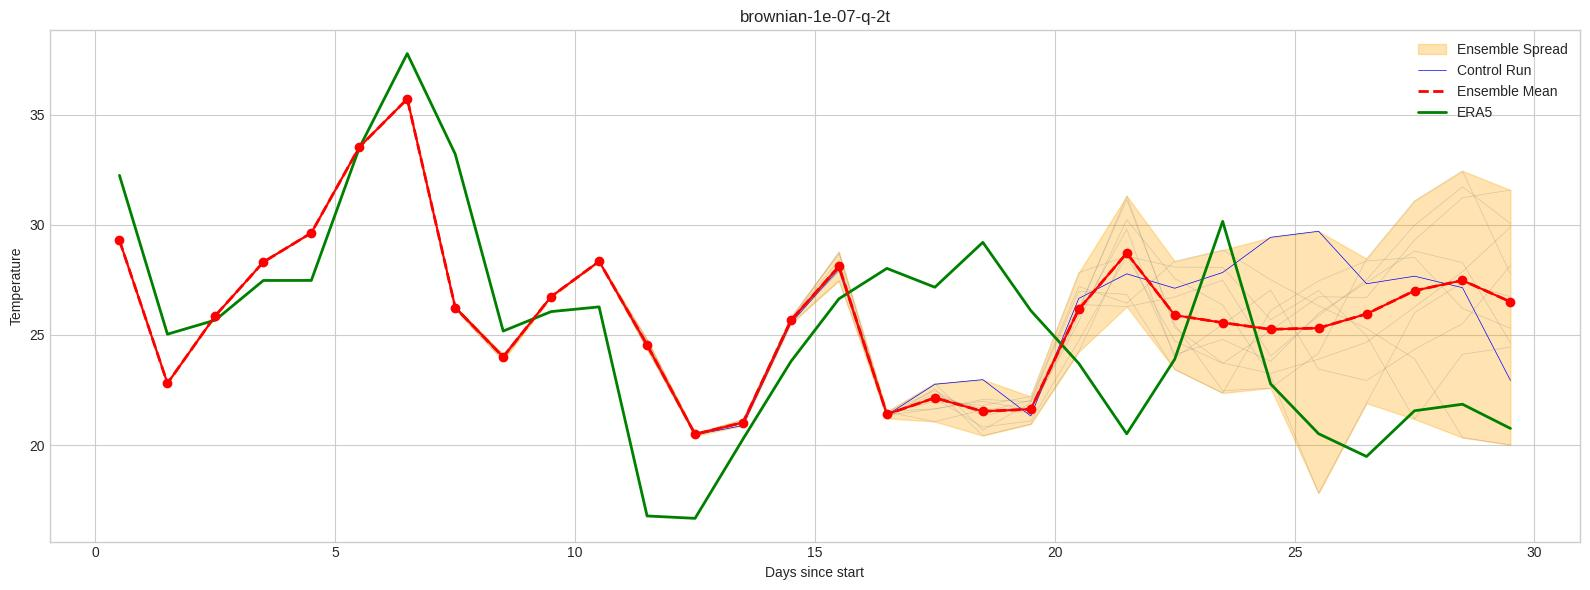

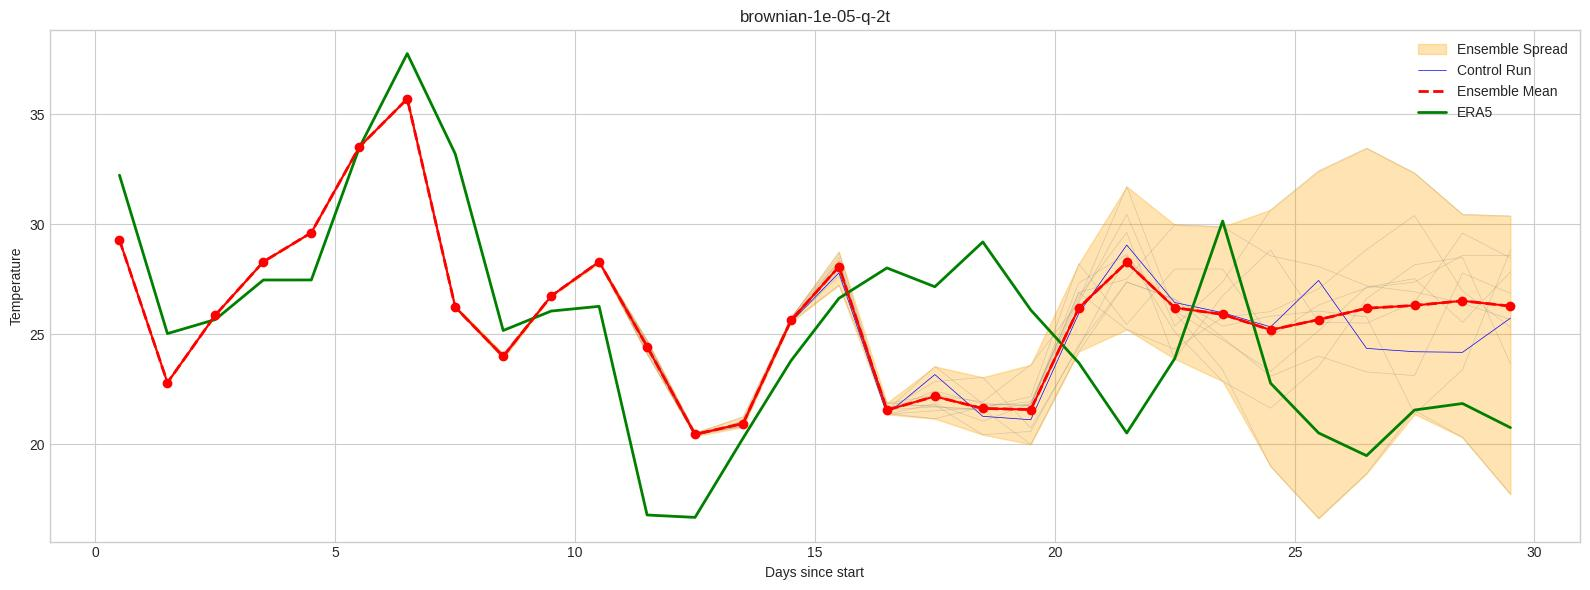

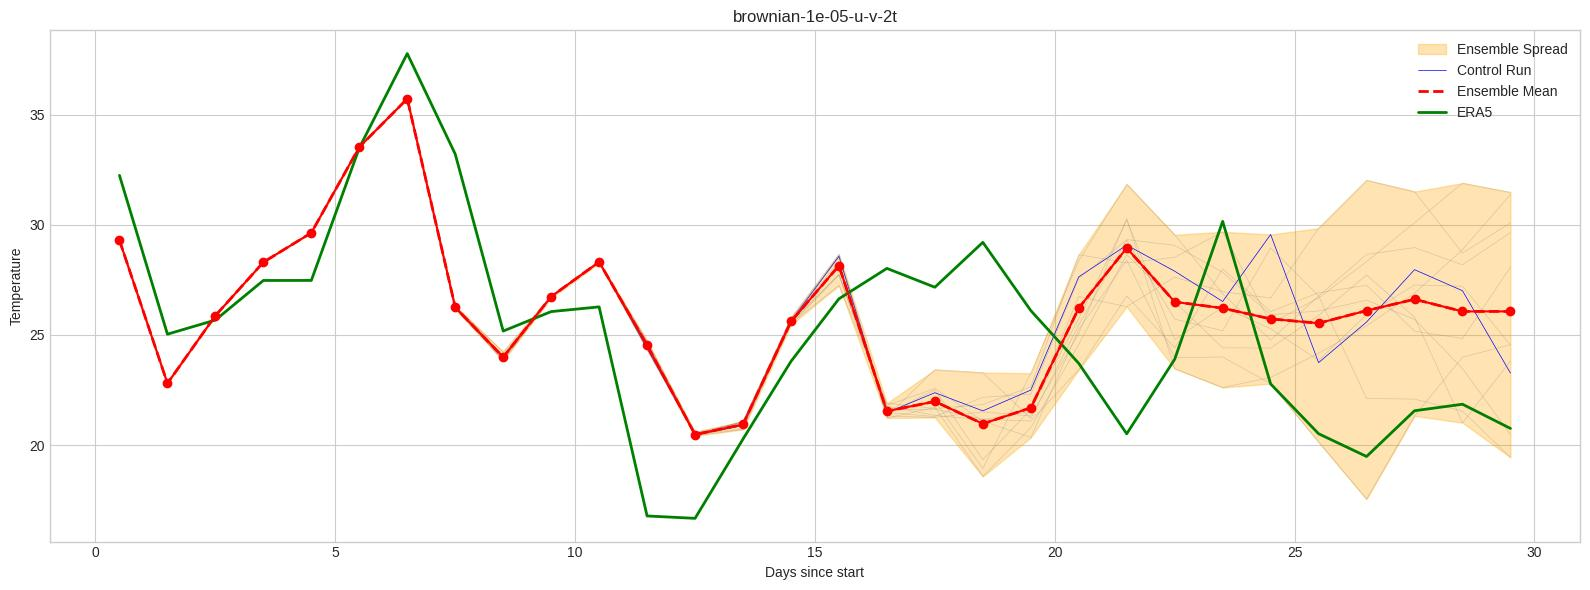

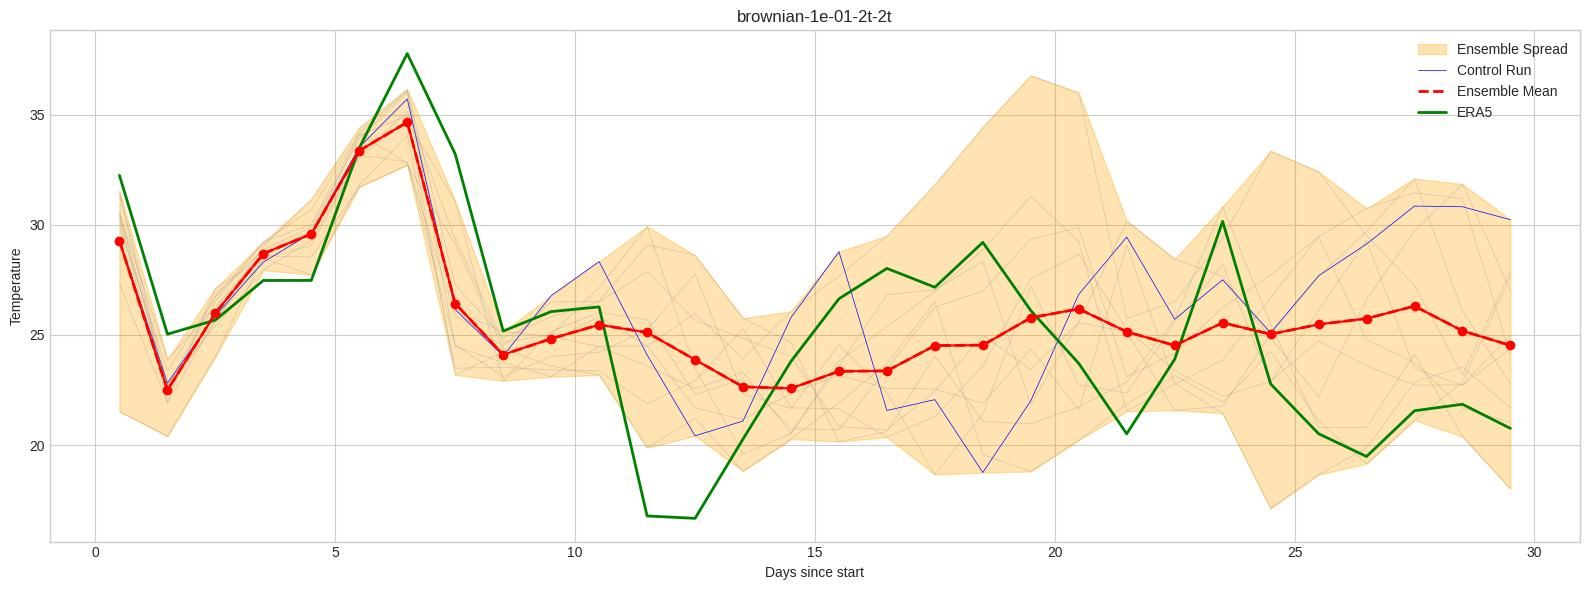

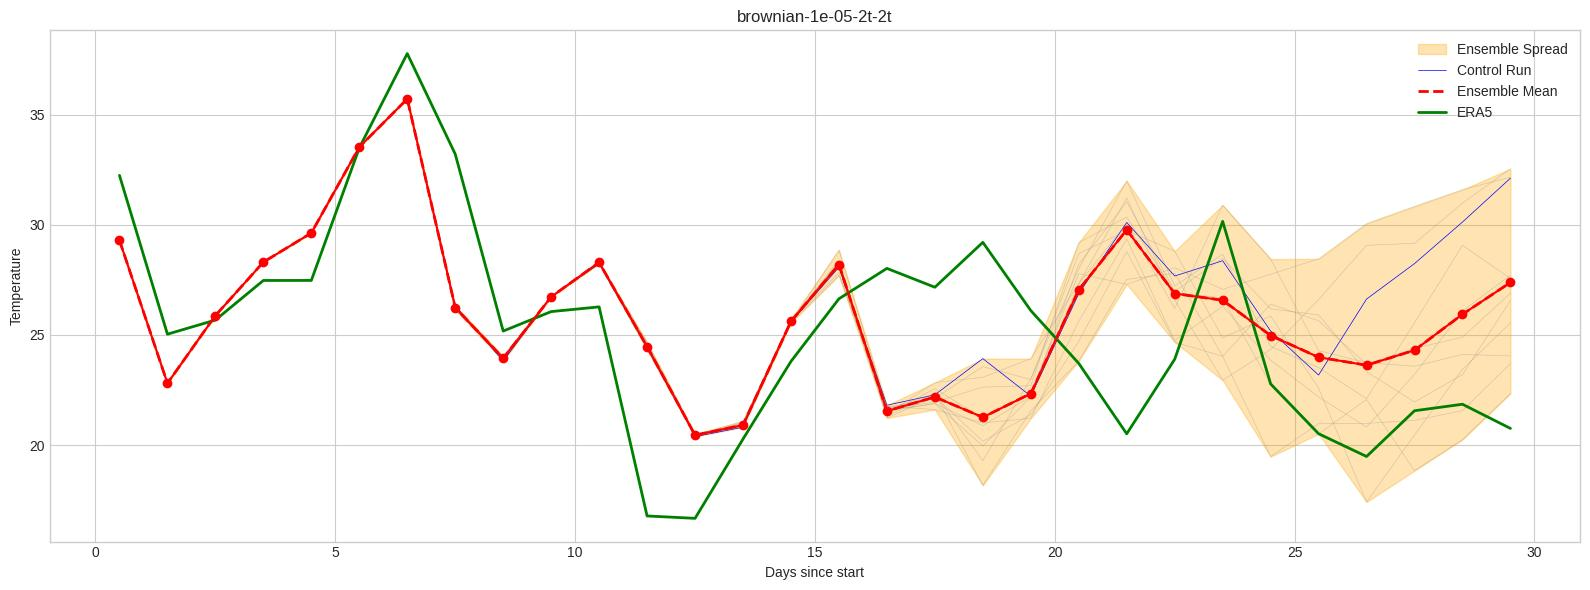

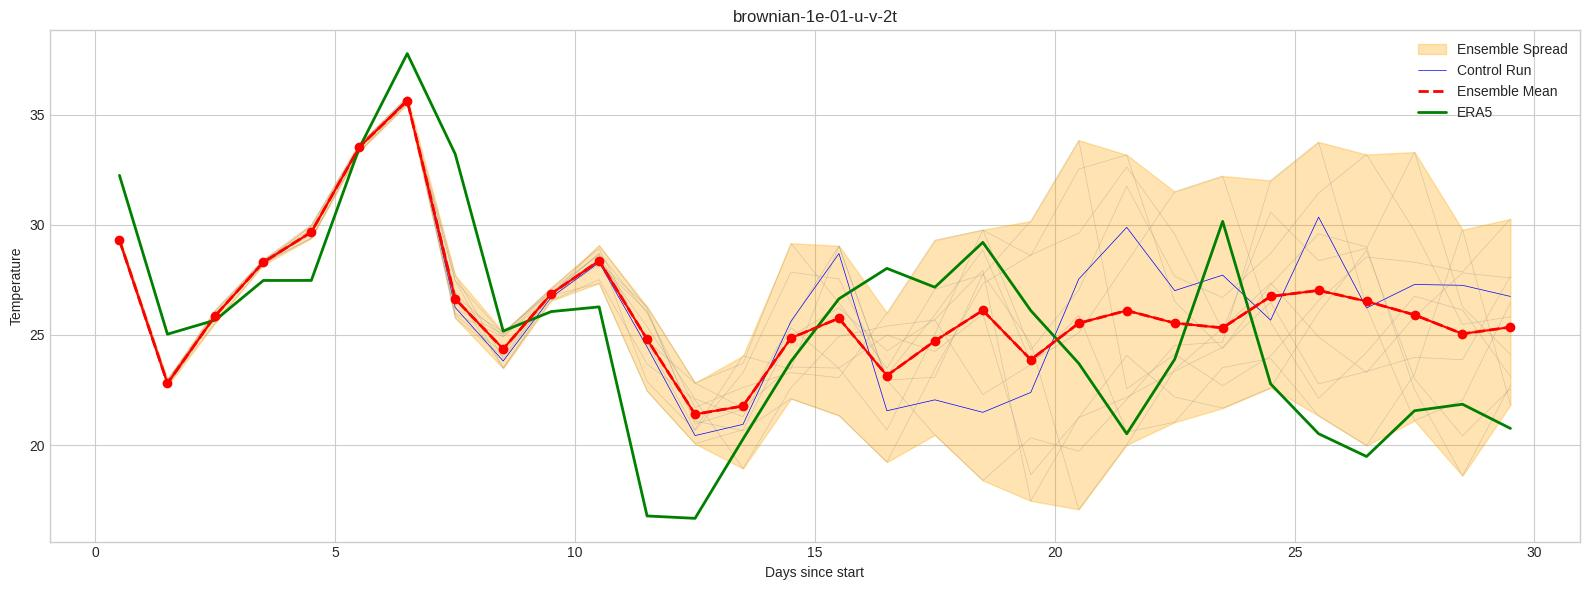

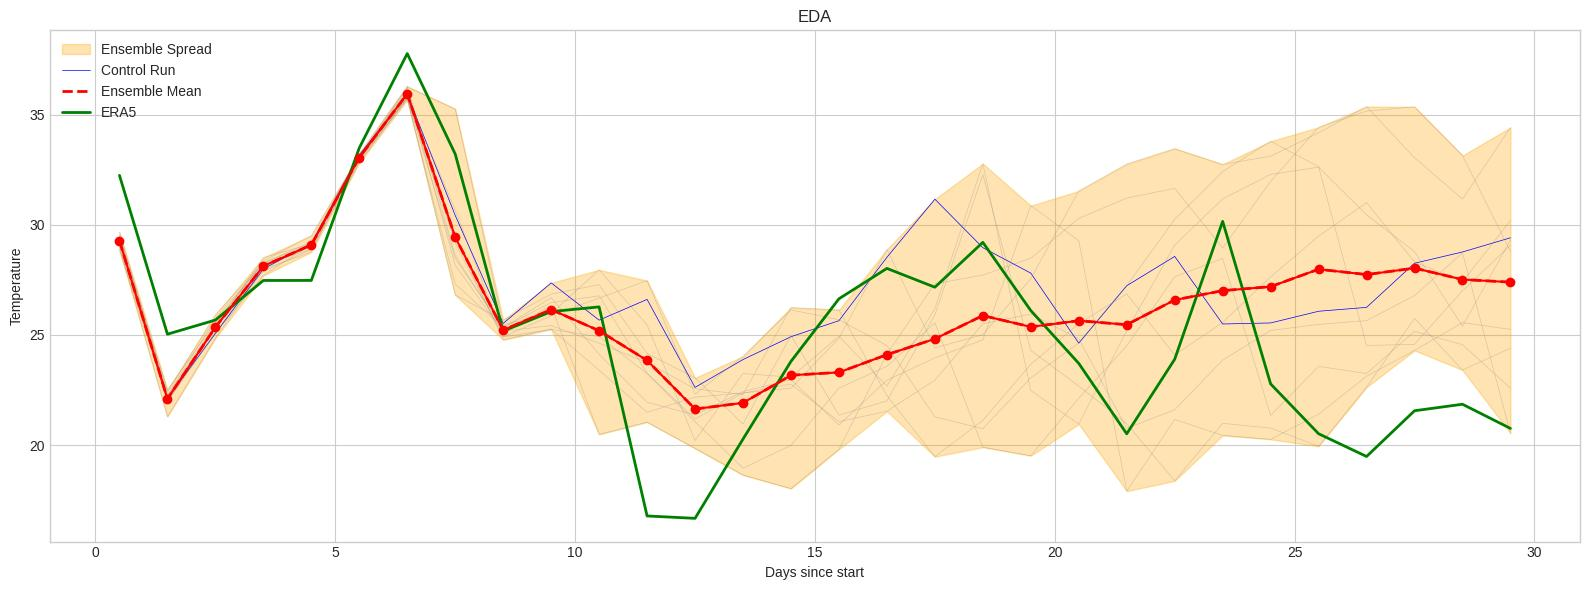

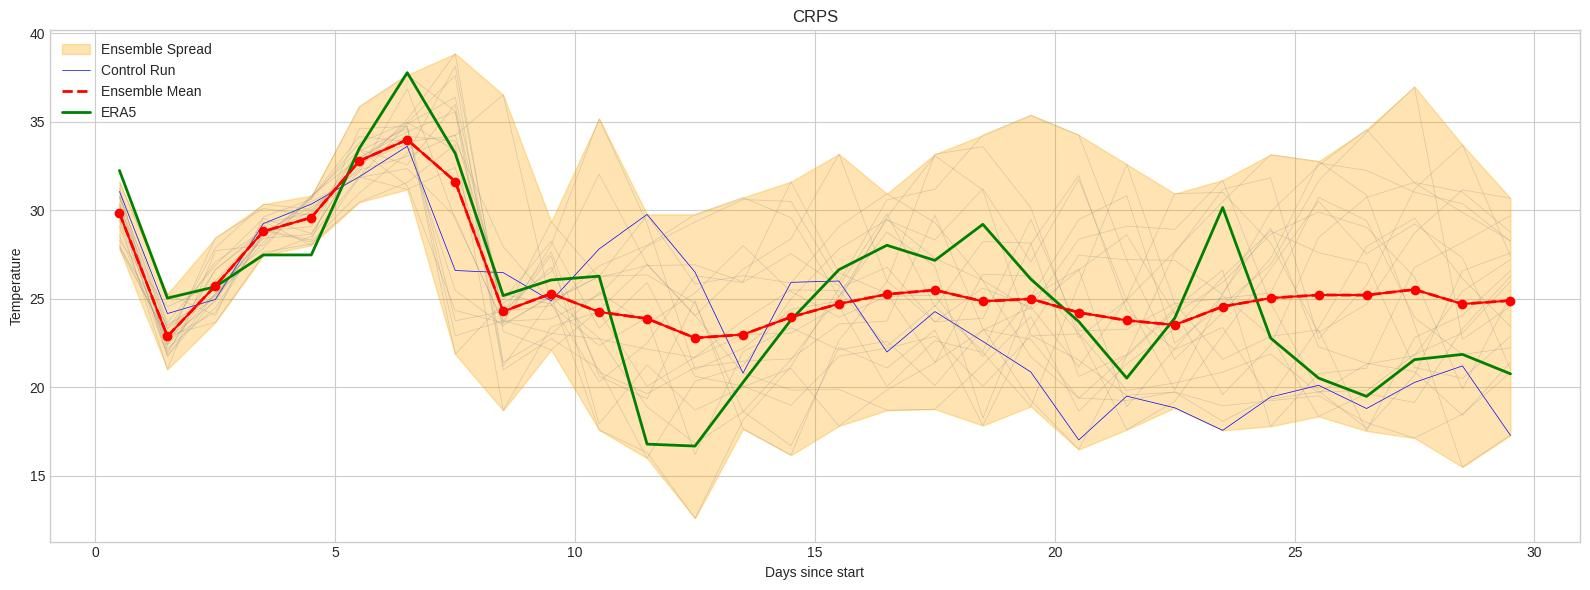

In [13]:
for k, v in datasets_results["2021061400"]["2t"].items():
    check_chaos(
        v.sel(latitude=paris_latitude, longitude=paris_longitude, method="nearest")[
            "2t"
        ]
        - 273.15,
        title=k,
        time_of_day=[12]
    )
for k, v in datasets_results["2025062500"]["2t"].items():
    check_chaos(
        v.sel(latitude=paris_latitude, longitude=paris_longitude, method="nearest")[
            "2t"
        ]
        - 273.15,
        title=k,
        era=era5_202506_07.sel(
            latitude=paris_latitude, longitude=paris_longitude, method="nearest"
        )["t2m"]-273.15,
        time_of_day=[12]
    )

uniform-1e-01-2t-2t


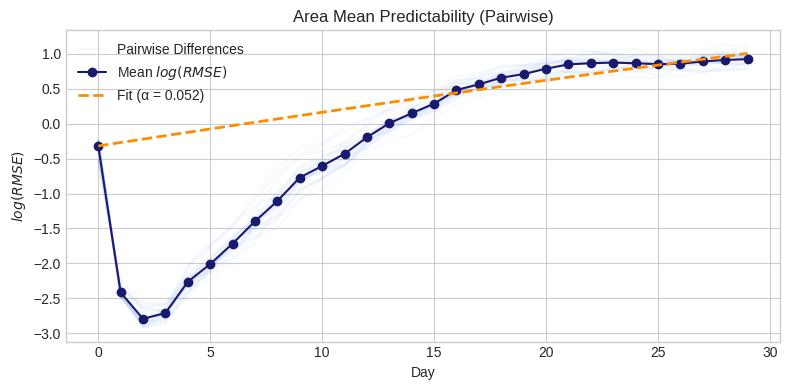

Estimated Growth Rate (α): 0.052 days^-1 | Saturation Error (E_inf): 12.644
uniform-1e-01-u-v-2t


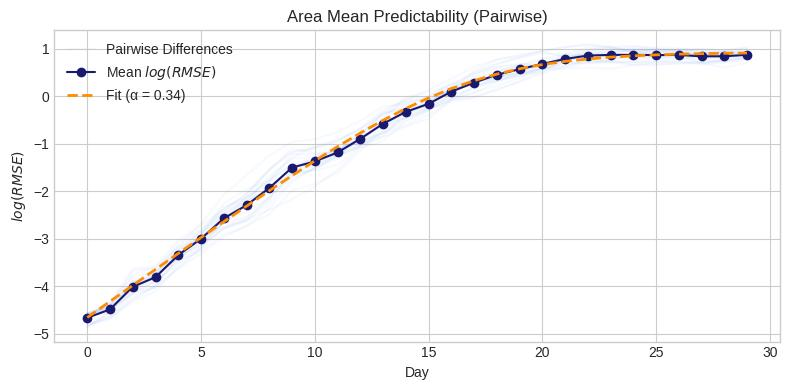

Estimated Growth Rate (α): 0.34 days^-1 | Saturation Error (E_inf): 2.524
uniform-1e-01-q-2t


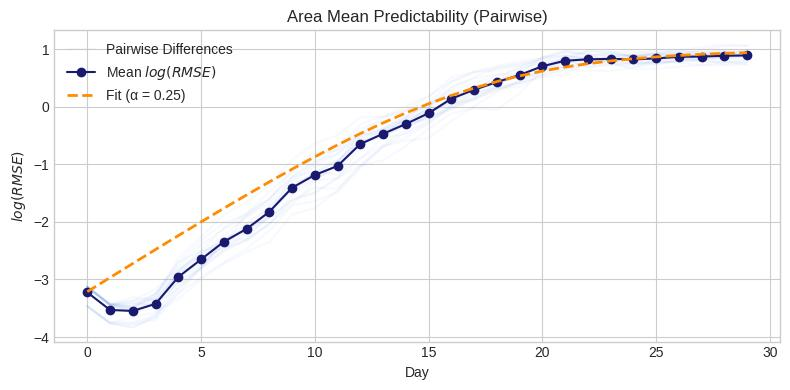

Estimated Growth Rate (α): 0.25 days^-1 | Saturation Error (E_inf): 2.689
uniform-1e-05-q-u-v-2t


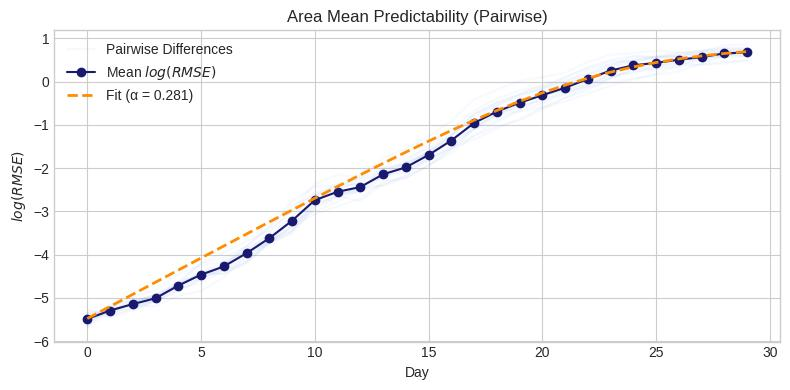

Estimated Growth Rate (α): 0.281 days^-1 | Saturation Error (E_inf): 2.322
uniform-1e-03-u-v-2t


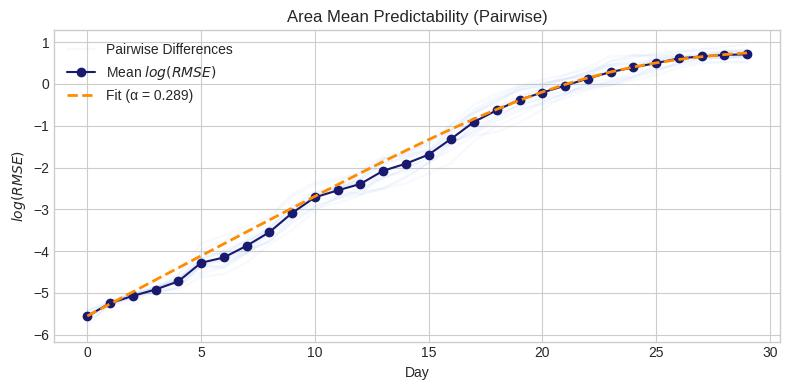

Estimated Growth Rate (α): 0.289 days^-1 | Saturation Error (E_inf): 2.401
uniform-1e-03-q-u-v-2t


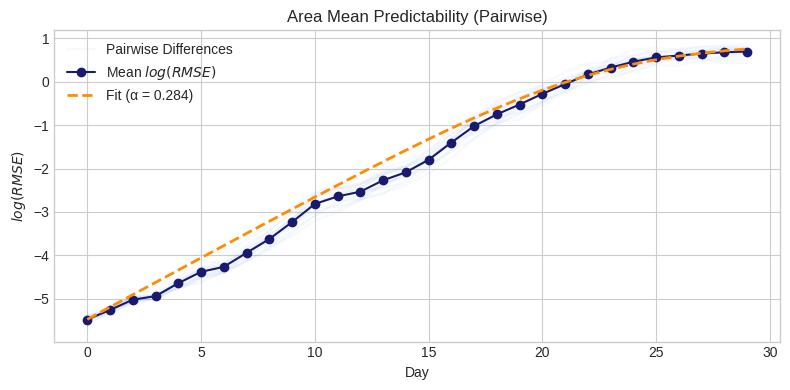

Estimated Growth Rate (α): 0.284 days^-1 | Saturation Error (E_inf): 2.444
uniform-1e-05-u-v-2t


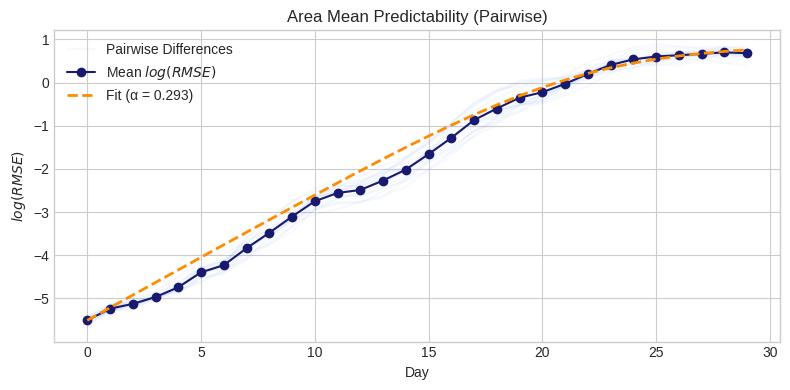

Estimated Growth Rate (α): 0.293 days^-1 | Saturation Error (E_inf): 2.389
uniform-1e-07-q-2t


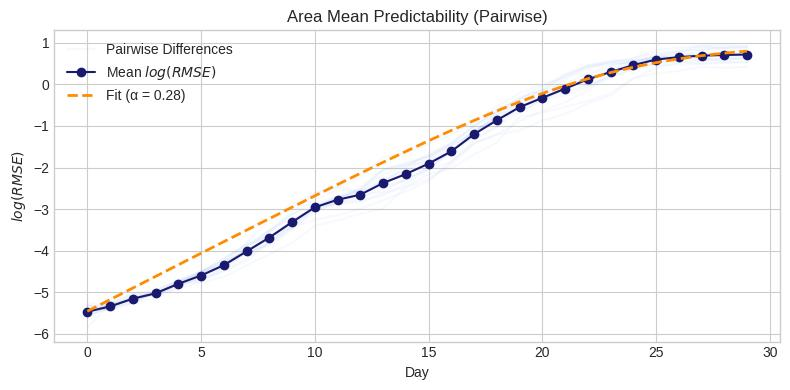

Estimated Growth Rate (α): 0.28 days^-1 | Saturation Error (E_inf): 2.632
uniform-1e-03-q-2t


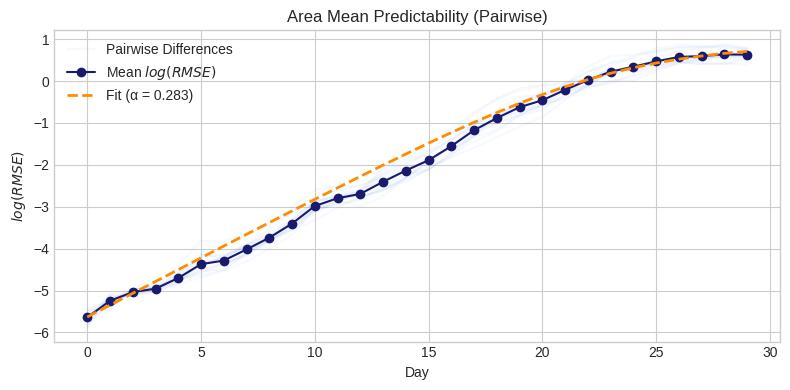

Estimated Growth Rate (α): 0.283 days^-1 | Saturation Error (E_inf): 2.399
uniform-1e-09-u-v-2t


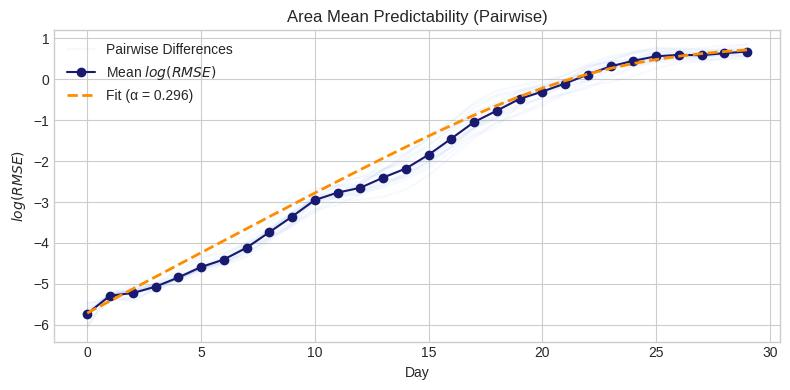

Estimated Growth Rate (α): 0.296 days^-1 | Saturation Error (E_inf): 2.316
uniform-1e-05-q-2t


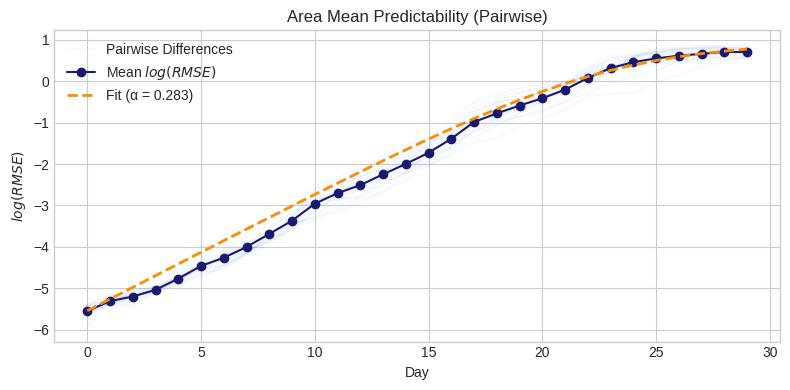

Estimated Growth Rate (α): 0.283 days^-1 | Saturation Error (E_inf): 2.563
uniform-1e-09-q-2t


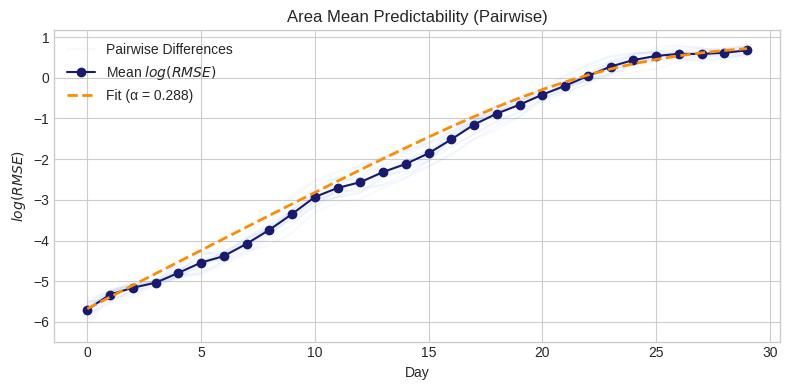

Estimated Growth Rate (α): 0.288 days^-1 | Saturation Error (E_inf): 2.384
uniform-1e-07-q-u-v-2t


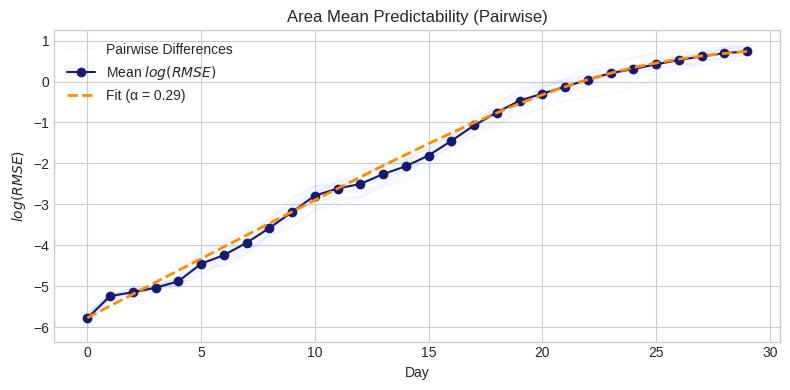

Estimated Growth Rate (α): 0.29 days^-1 | Saturation Error (E_inf): 2.461
uniform-1e-07-u-v-2t


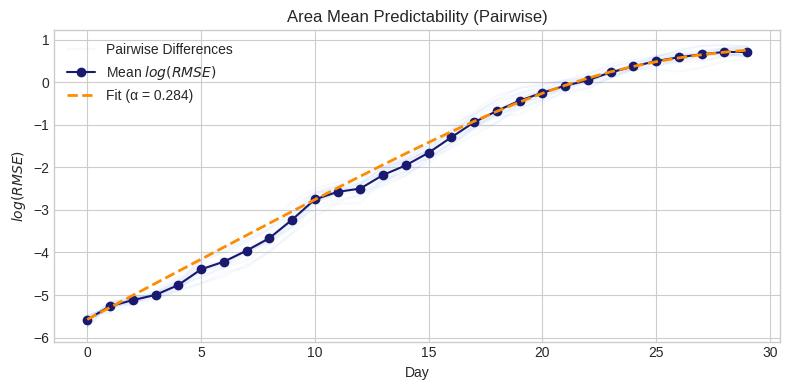

Estimated Growth Rate (α): 0.284 days^-1 | Saturation Error (E_inf): 2.488
uniform-1e-09-q-u-v-2t


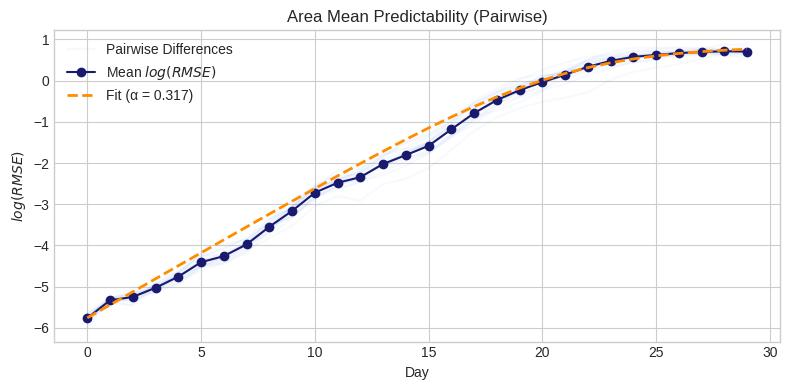

Estimated Growth Rate (α): 0.317 days^-1 | Saturation Error (E_inf): 2.304
gaussian-1e-03-q-u-v-2t


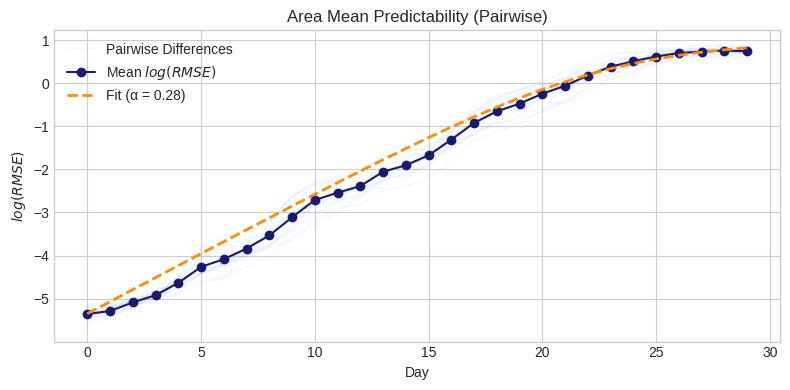

Estimated Growth Rate (α): 0.28 days^-1 | Saturation Error (E_inf): 2.662
gaussian-1e-03-u-v-2t


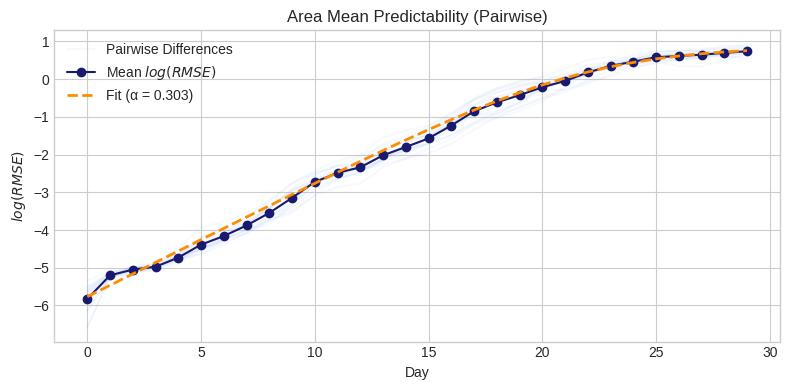

Estimated Growth Rate (α): 0.303 days^-1 | Saturation Error (E_inf): 2.381
gaussian-1e-09-q-u-v-2t


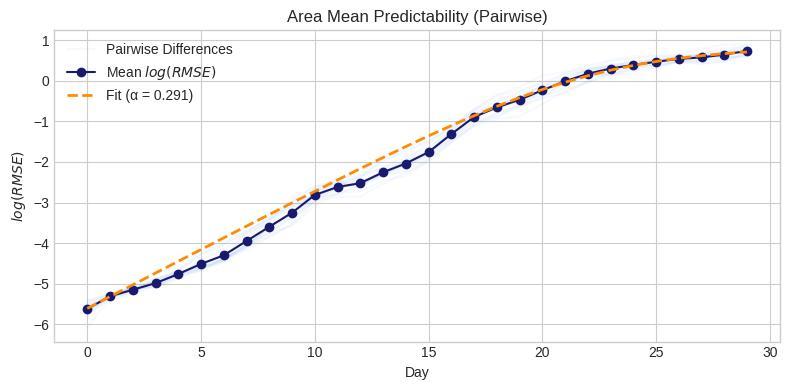

Estimated Growth Rate (α): 0.291 days^-1 | Saturation Error (E_inf): 2.306
gaussian-1e-07-q-2t


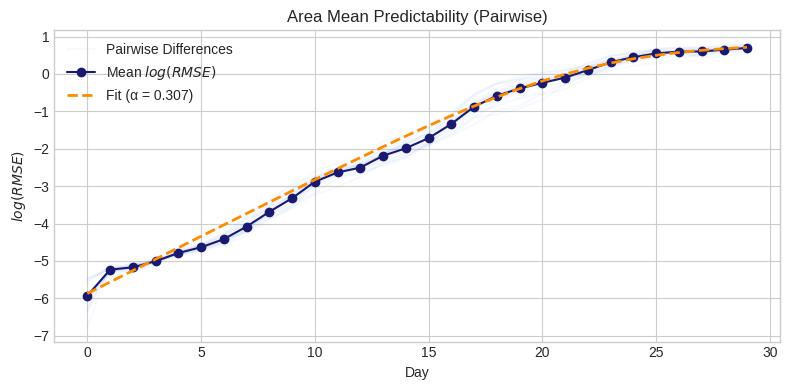

Estimated Growth Rate (α): 0.307 days^-1 | Saturation Error (E_inf): 2.263
gaussian-1e-09-u-v-2t


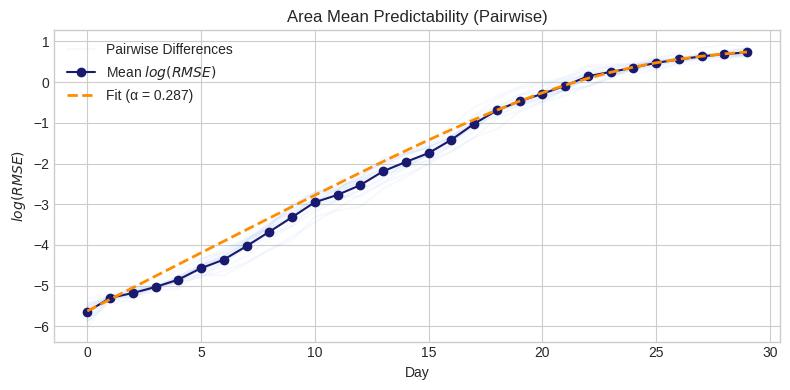

Estimated Growth Rate (α): 0.287 days^-1 | Saturation Error (E_inf): 2.44
gaussian-1e-07-u-v-2t


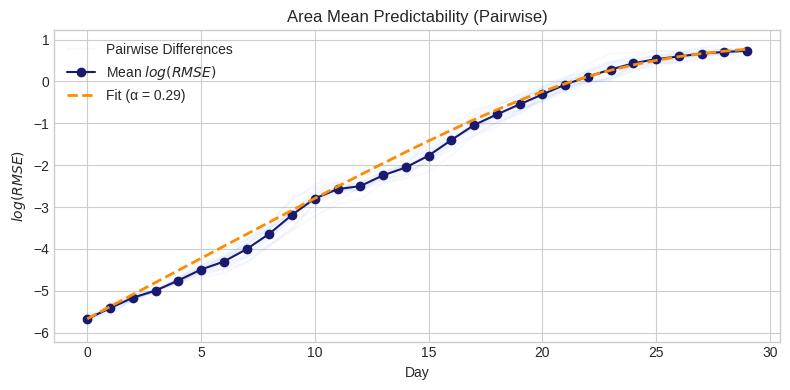

Estimated Growth Rate (α): 0.29 days^-1 | Saturation Error (E_inf): 2.509
gaussian-1e-07-q-u-v-2t


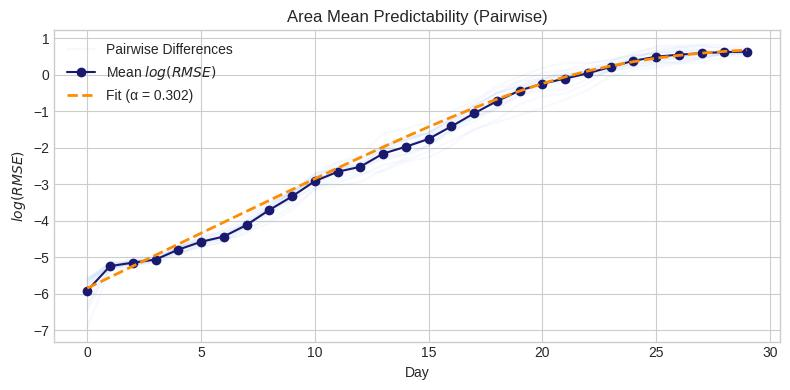

Estimated Growth Rate (α): 0.302 days^-1 | Saturation Error (E_inf): 2.195
gaussian-1e-05-u-v-2t


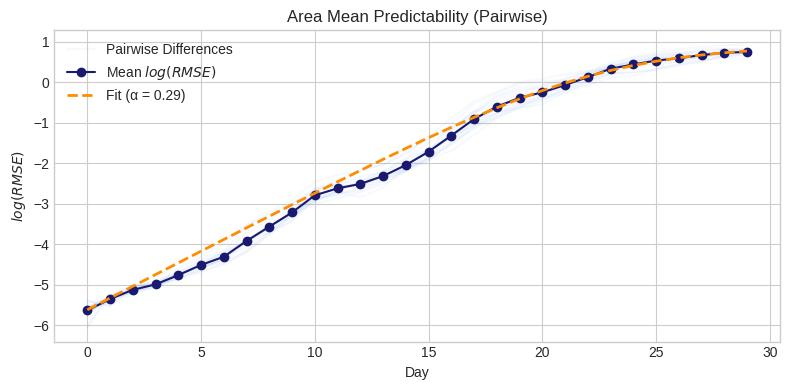

Estimated Growth Rate (α): 0.29 days^-1 | Saturation Error (E_inf): 2.485
gaussian-1e-03-q-2t


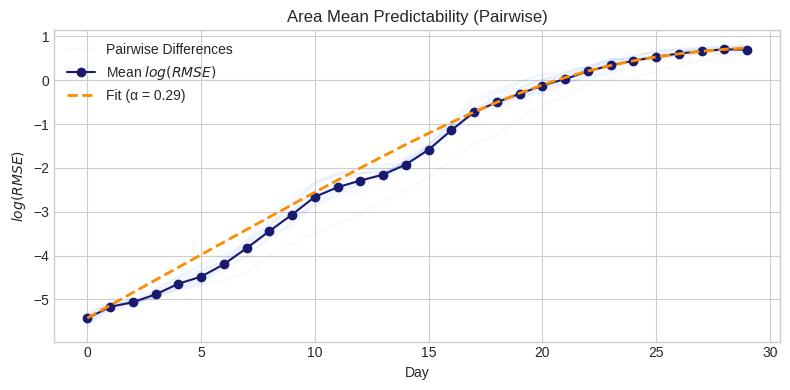

Estimated Growth Rate (α): 0.29 days^-1 | Saturation Error (E_inf): 2.342
gaussian-1e-09-q-2t


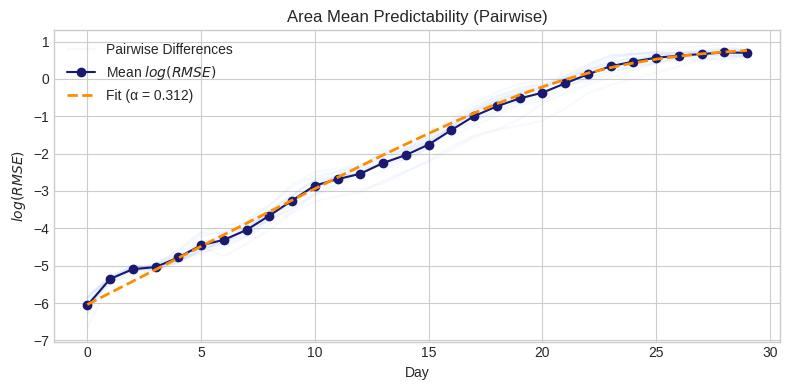

Estimated Growth Rate (α): 0.312 days^-1 | Saturation Error (E_inf): 2.387
gaussian-1e-05-q-2t


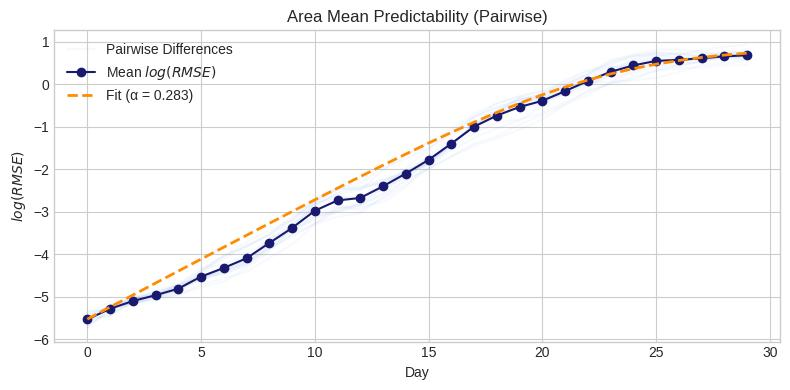

Estimated Growth Rate (α): 0.283 days^-1 | Saturation Error (E_inf): 2.41
gaussian-1e-05-q-u-v-2t


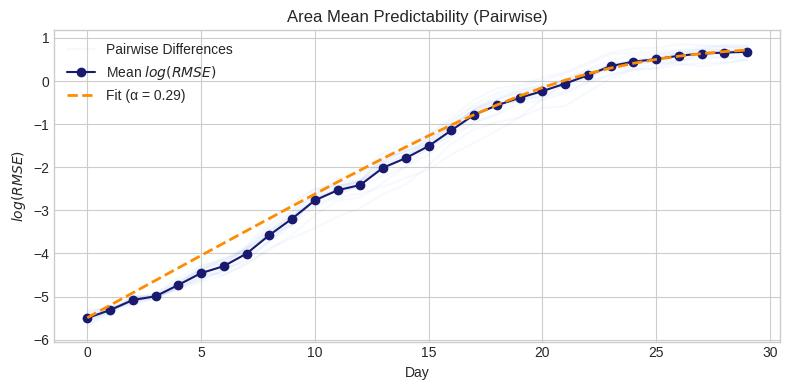

Estimated Growth Rate (α): 0.29 days^-1 | Saturation Error (E_inf): 2.312
brownian-1e-03-q-2t


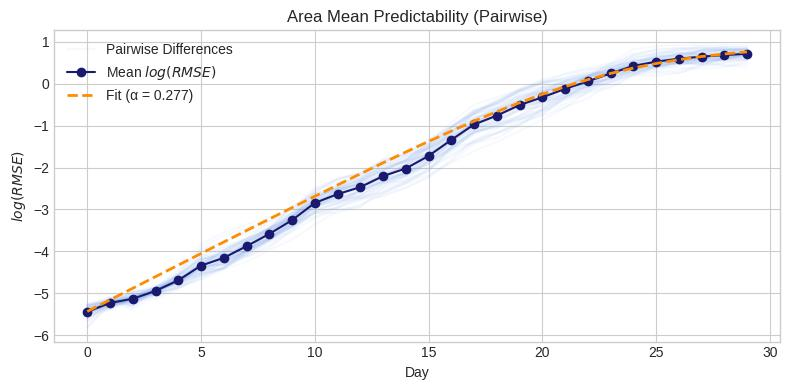

Estimated Growth Rate (α): 0.277 days^-1 | Saturation Error (E_inf): 2.527
brownian-1e-07-2t-2t


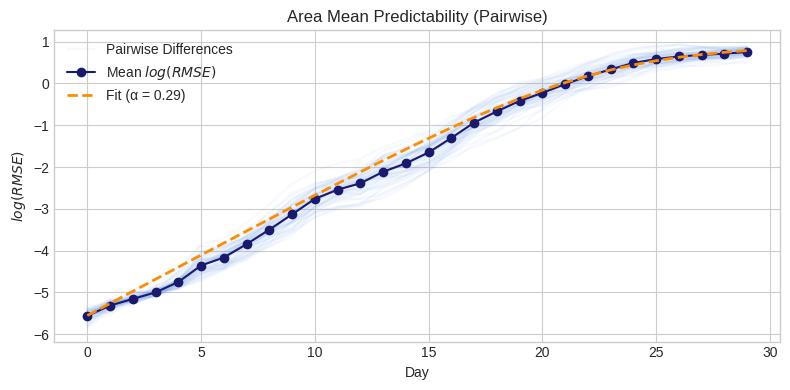

Estimated Growth Rate (α): 0.29 days^-1 | Saturation Error (E_inf): 2.506
brownian-1e-01-q-2t


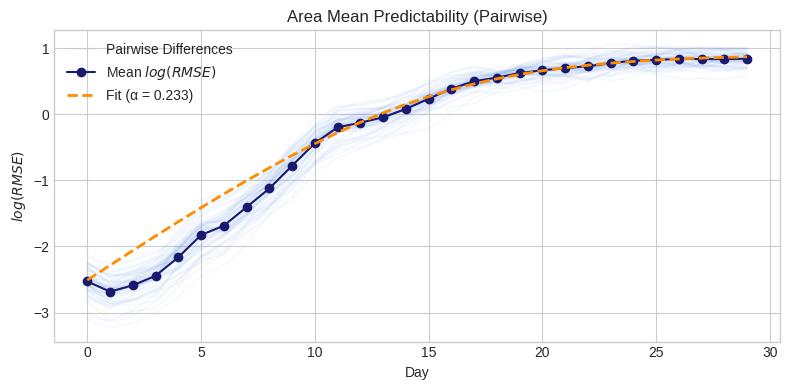

Estimated Growth Rate (α): 0.233 days^-1 | Saturation Error (E_inf): 2.463
brownian-1e-03-2t-2t


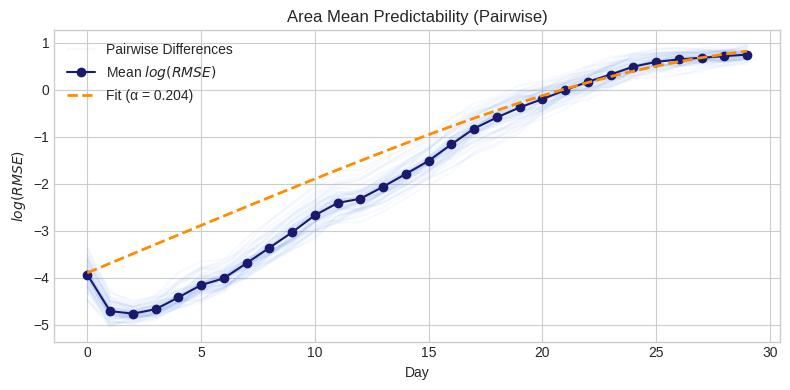

Estimated Growth Rate (α): 0.204 days^-1 | Saturation Error (E_inf): 3.274
brownian-1e-07-u-v-2t


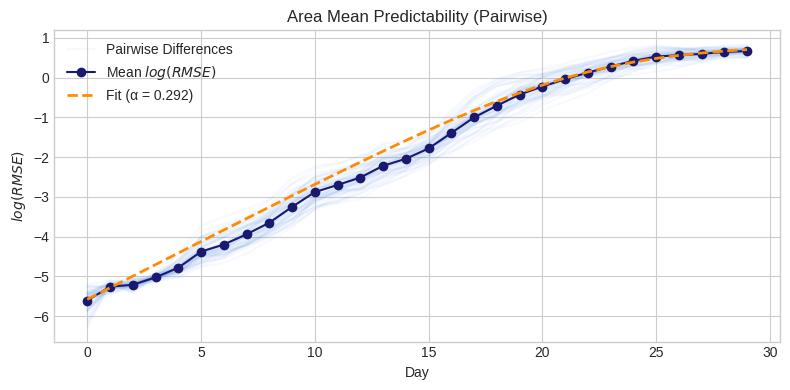

Estimated Growth Rate (α): 0.292 days^-1 | Saturation Error (E_inf): 2.283
brownian-1e-03-u-v-2t


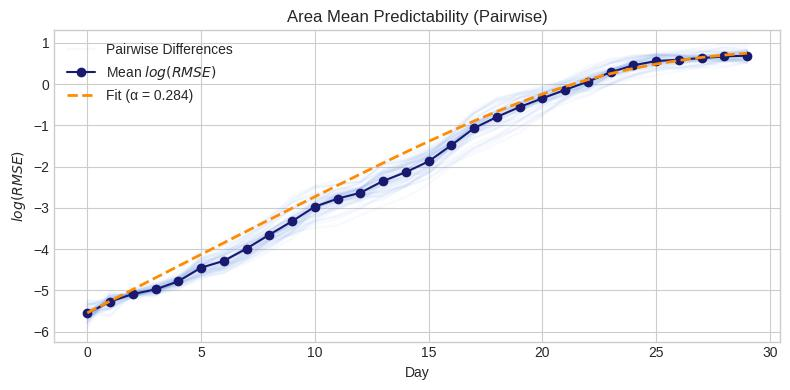

Estimated Growth Rate (α): 0.284 days^-1 | Saturation Error (E_inf): 2.478
brownian-1e-07-q-2t


/home/pchevali/Stage2026/Notebooks/ensemble_chaos_tools.py:764: RuntimeWarning: divide by zero encountered in log
  logdist = np.log(pairwise_rmse)


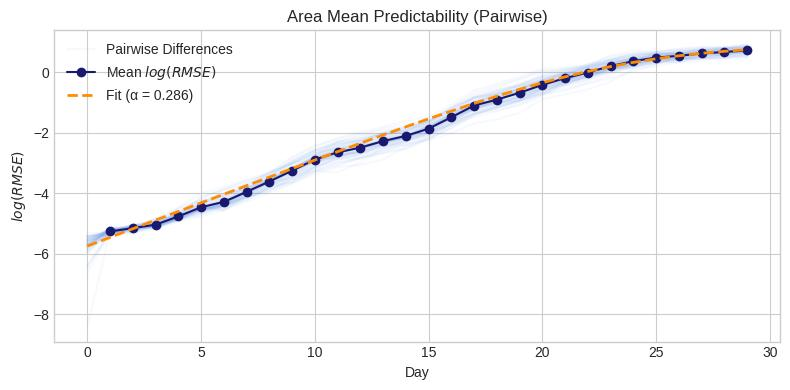

Estimated Growth Rate (α): 0.286 days^-1 | Saturation Error (E_inf): 2.504
brownian-1e-05-q-2t


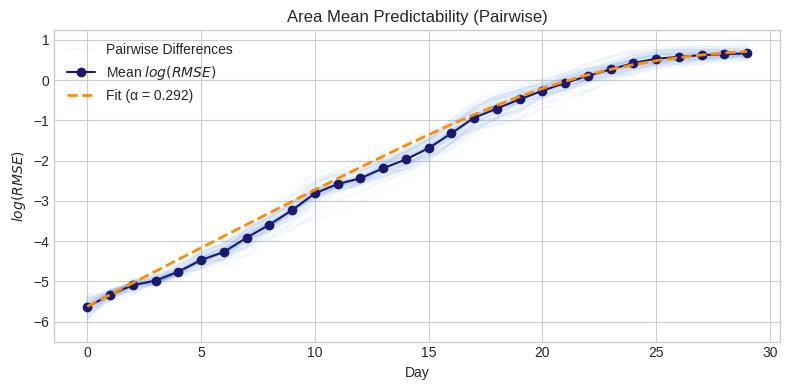

Estimated Growth Rate (α): 0.292 days^-1 | Saturation Error (E_inf): 2.315
brownian-1e-05-u-v-2t


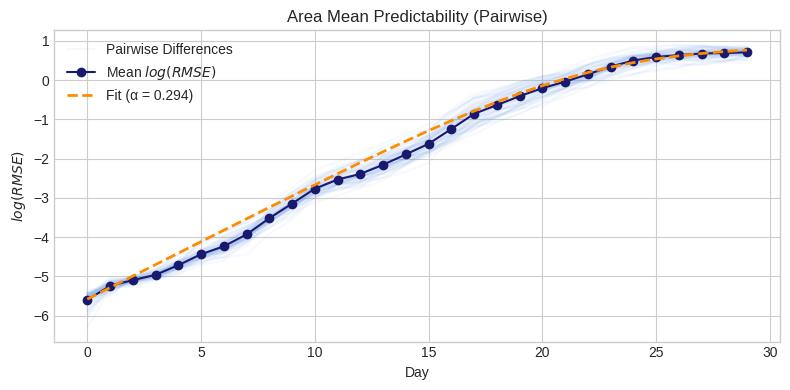

Estimated Growth Rate (α): 0.294 days^-1 | Saturation Error (E_inf): 2.417
brownian-1e-01-2t-2t


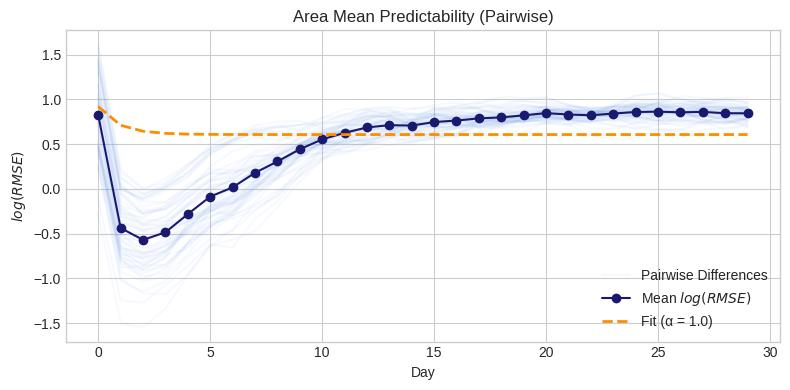

Estimated Growth Rate (α): 1.0 days^-1 | Saturation Error (E_inf): 1.835
brownian-1e-05-2t-2t


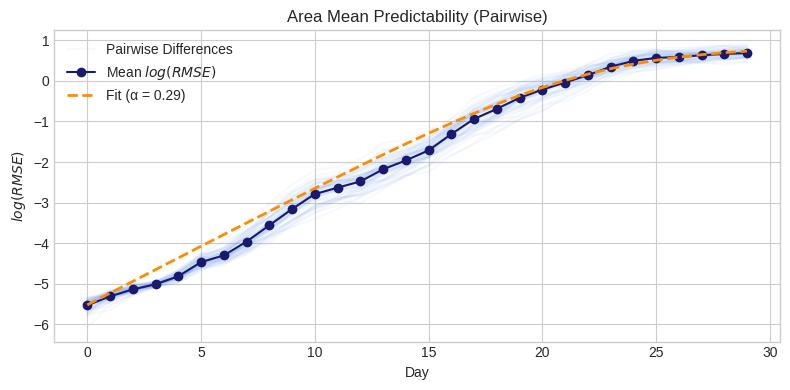

Estimated Growth Rate (α): 0.29 days^-1 | Saturation Error (E_inf): 2.353
brownian-1e-01-u-v-2t


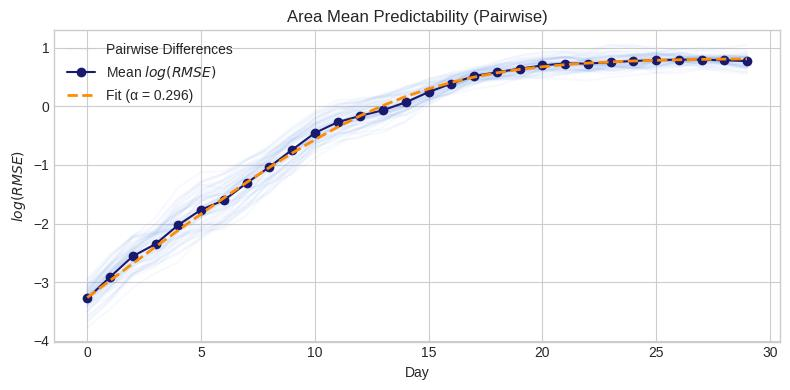

Estimated Growth Rate (α): 0.296 days^-1 | Saturation Error (E_inf): 2.267
EDA


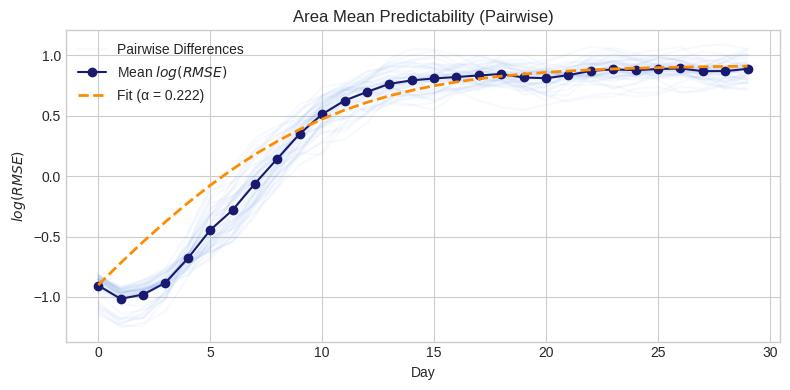

Estimated Growth Rate (α): 0.222 days^-1 | Saturation Error (E_inf): 2.508
CRPS


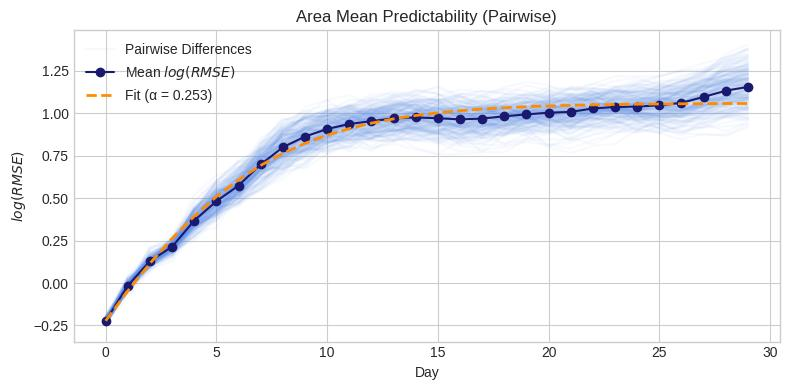

Estimated Growth Rate (α): 0.253 days^-1 | Saturation Error (E_inf): 2.882


In [14]:
for k, v in chaos_results["2021061400"]["2t"].items():
    print(k)
    v.growth_rate_pairwise(
        lat=northern_hemisphere_latitude_bnd,
        lon=northern_hemisphere_longitude_bnd,
        times=[12],
    )
for k, v in chaos_results["2025062500"]["2t"].items():
    print(k)
    v.growth_rate_pairwise(
        lat=northern_hemisphere_latitude_bnd,
        lon=northern_hemisphere_longitude_bnd,
        times=[12],
    )

### Fields vs ERA5

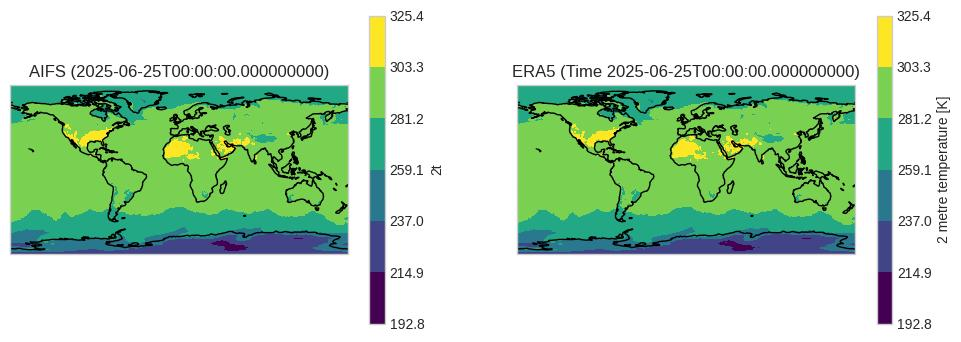

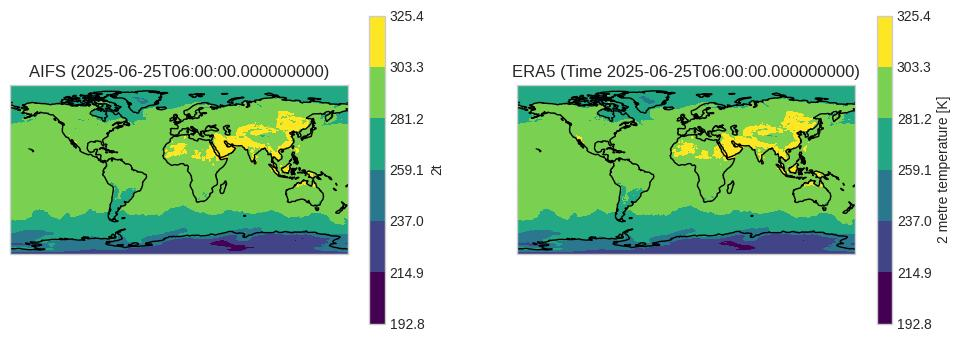

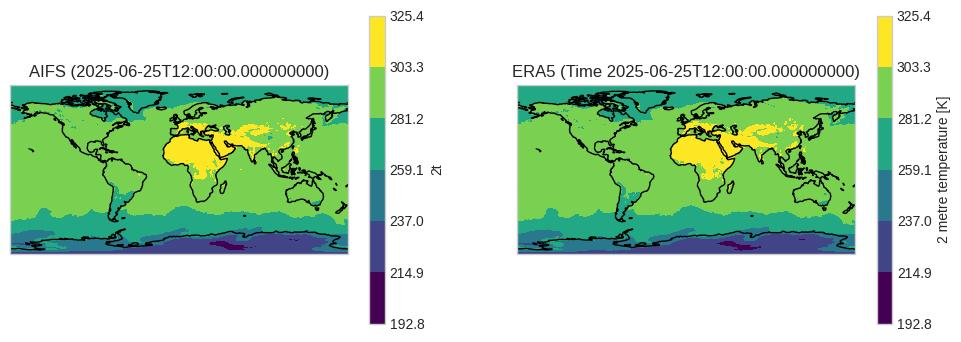

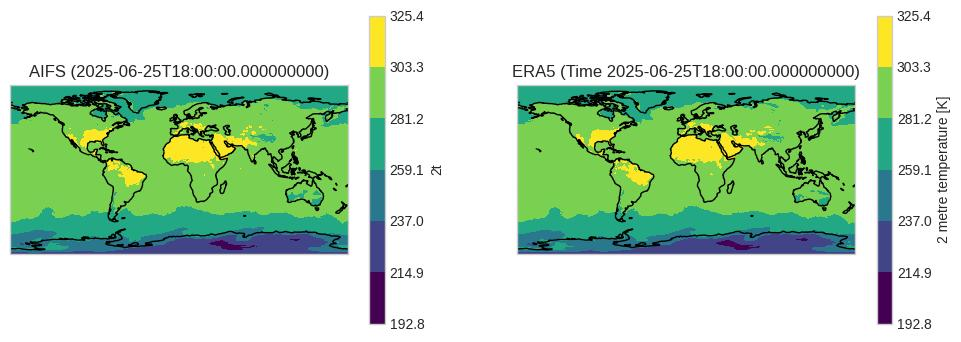

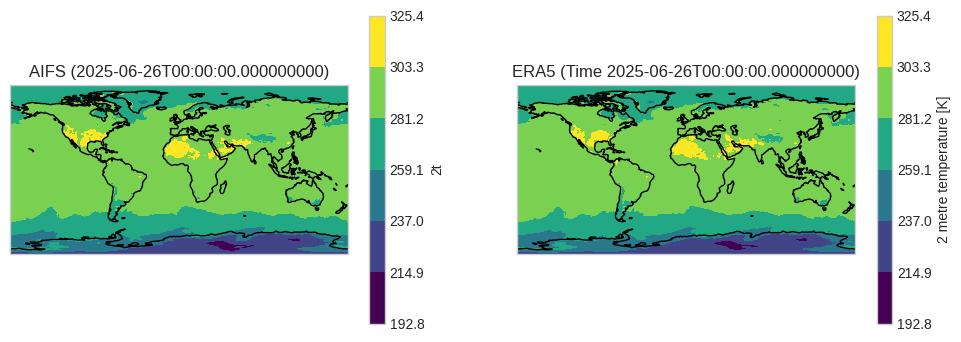

In [15]:
vmax_pred = (
    chaos_results["2025062500"]["2t"]["CRPS"].perturbed.sel(number=4)["2t"].max().item()
)
vmin_pred = (
    chaos_results["2025062500"]["2t"]["CRPS"].perturbed.sel(number=4)["2t"].min().item()
)

vmax_era5 = era5_202506_07["t2m"].max().item()
vmin_era5 = era5_202506_07["t2m"].min().item()

vmax = max(vmax_pred, vmax_era5)
vmin = min(vmin_pred, vmin_era5)

aifs_valid_times = (
    chaos_results["2025062500"]["2t"]["CRPS"].perturbed.sel(number=4).valid_time.values
)
era5_times = era5_202506_07.time.values

for i in range(5):
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 4), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    chaos_results["2025062500"]["2t"]["CRPS"].perturbed.sel(number=4).isel(step=i)[
        "2t"
    ].plot.contourf(ax=ax1, vmin=vmin, vmax=vmax)
    ax1.coastlines()
    ax1.set_title(f"AIFS ({aifs_valid_times[i]})")

    era5_202506_07.isel(time=i)["t2m"].plot.contourf(ax=ax2, vmin=vmin, vmax=vmax)
    ax2.coastlines()
    ax2.set_title(f"ERA5 (Time {era5_times[i]})")

    plt.show()

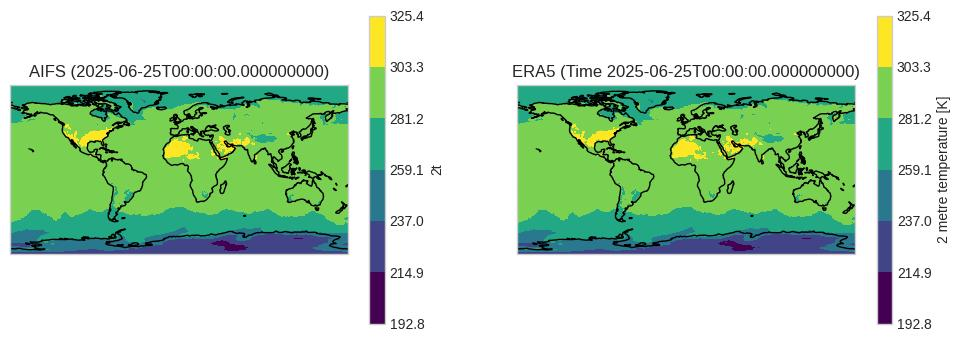

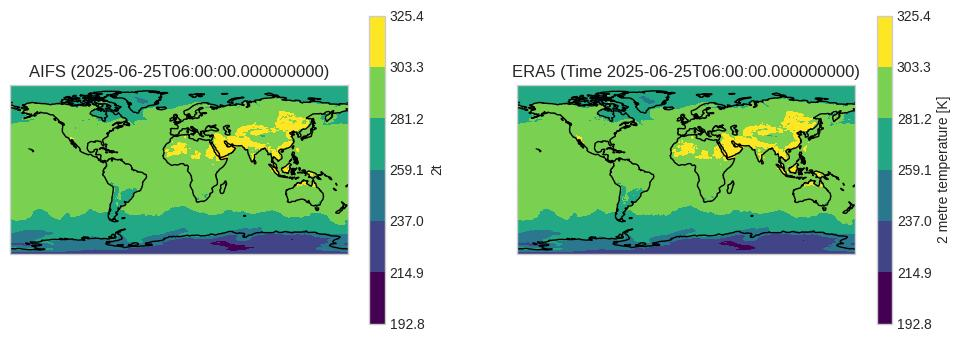

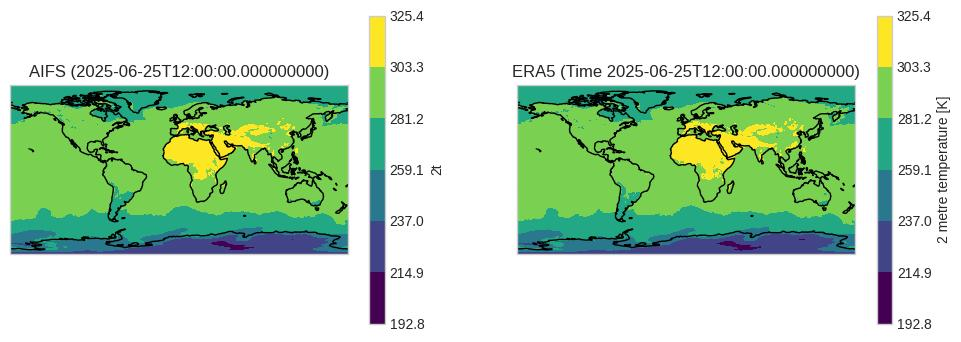

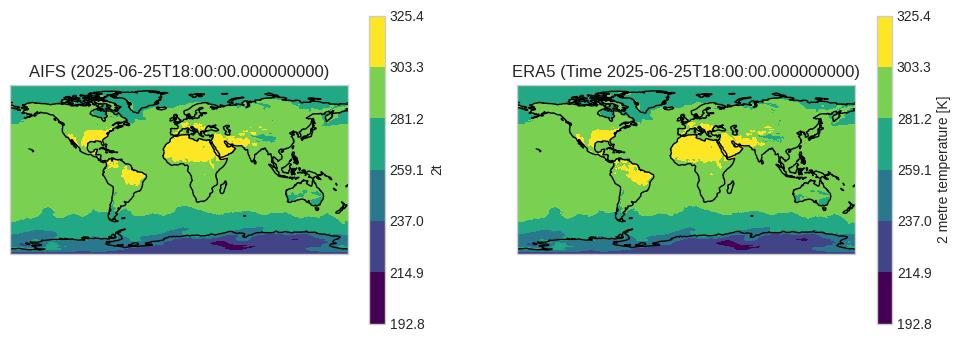

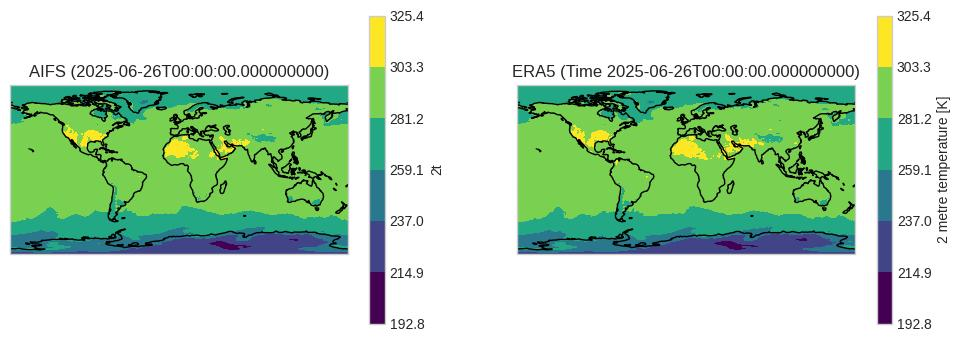

In [16]:
vmax_pred = (
    chaos_results["2025062500"]["2t"]["brownian-1e-01-u-v-2t"]
    .perturbed.sel(number=4)["2t"]
    .max()
    .item()
)
vmin_pred = (
    chaos_results["2025062500"]["2t"]["brownian-1e-01-u-v-2t"]
    .perturbed.sel(number=4)["2t"]
    .min()
    .item()
)

vmax_era5 = era5_202506_07["t2m"].max().item()
vmin_era5 = era5_202506_07["t2m"].min().item()

vmax = max(vmax_pred, vmax_era5)
vmin = min(vmin_pred, vmin_era5)

aifs_valid_times = (
    chaos_results["2025062500"]["2t"]["brownian-1e-01-u-v-2t"]
    .perturbed.sel(number=4)
    .valid_time.values
)
era5_times = era5_202506_07.time.values

for i in range(5):
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 4), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    chaos_results["2025062500"]["2t"]["brownian-1e-01-u-v-2t"].perturbed.sel(
        number=4
    ).isel(step=i)["2t"].plot.contourf(ax=ax1, vmin=vmin, vmax=vmax)
    ax1.coastlines()
    ax1.set_title(f"AIFS ({aifs_valid_times[i]})")

    era5_202506_07.isel(time=i)["t2m"].plot.contourf(ax=ax2, vmin=vmin, vmax=vmax)
    ax2.coastlines()
    ax2.set_title(f"ERA5 (Time {era5_times[i]})")

    plt.show()

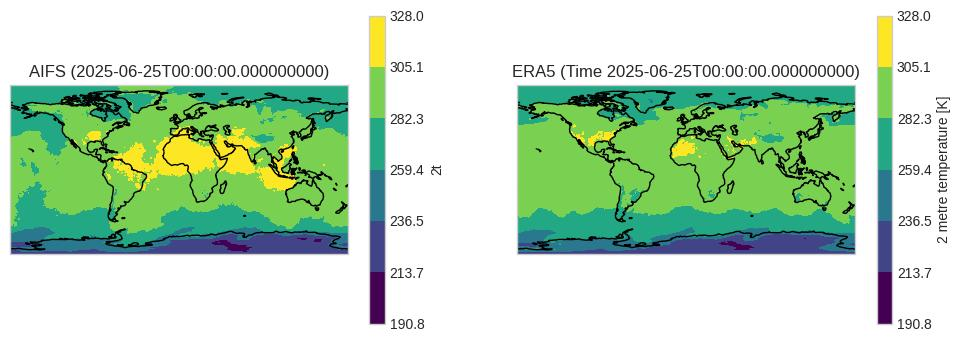

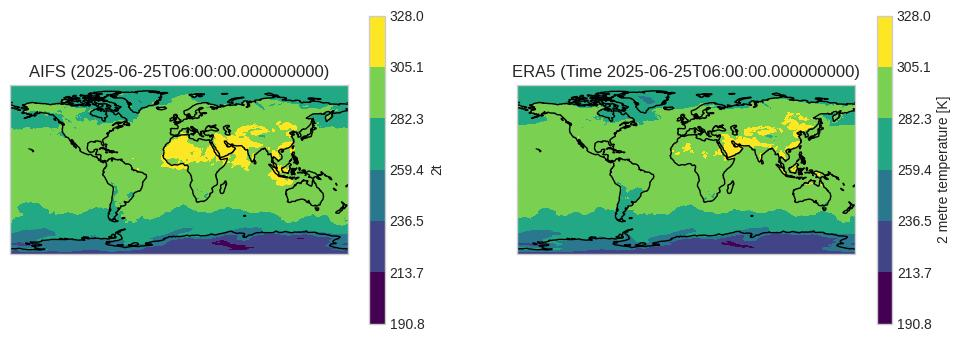

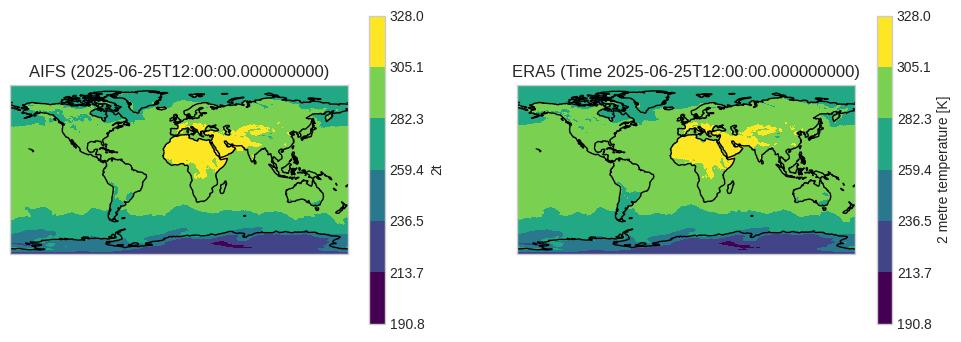

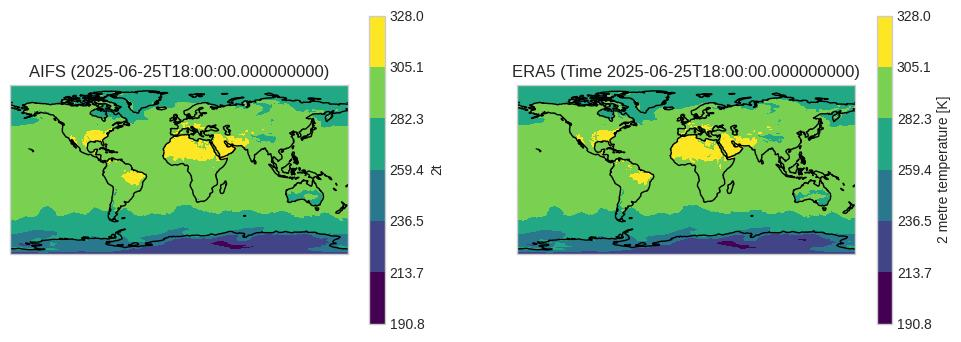

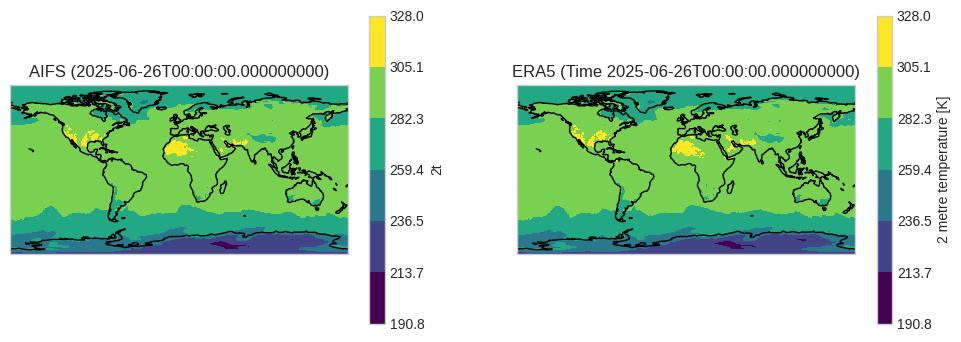

In [17]:
vmax_pred = (
    chaos_results["2025062500"]["2t"]["brownian-1e-01-2t-2t"]
    .perturbed.sel(number=4)["2t"]
    .max()
    .item()
)
vmin_pred = (
    chaos_results["2025062500"]["2t"]["brownian-1e-01-2t-2t"]
    .perturbed.sel(number=4)["2t"]
    .min()
    .item()
)

vmax_era5 = era5_202506_07["t2m"].max().item()
vmin_era5 = era5_202506_07["t2m"].min().item()

vmax = max(vmax_pred, vmax_era5)
vmin = min(vmin_pred, vmin_era5)

aifs_valid_times = (
    chaos_results["2025062500"]["2t"]["brownian-1e-01-2t-2t"]
    .perturbed.sel(number=4)
    .valid_time.values
)
era5_times = era5_202506_07.time.values

for i in range(5):
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 4), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    chaos_results["2025062500"]["2t"]["brownian-1e-01-2t-2t"].perturbed.sel(
        number=4
    ).isel(step=i)["2t"].plot.contourf(ax=ax1, vmin=vmin, vmax=vmax)
    ax1.coastlines()
    ax1.set_title(f"AIFS ({aifs_valid_times[i]})")

    era5_202506_07.isel(time=i)["t2m"].plot.contourf(ax=ax2, vmin=vmin, vmax=vmax)
    ax2.coastlines()
    ax2.set_title(f"ERA5 (Time {era5_times[i]})")

    plt.show()

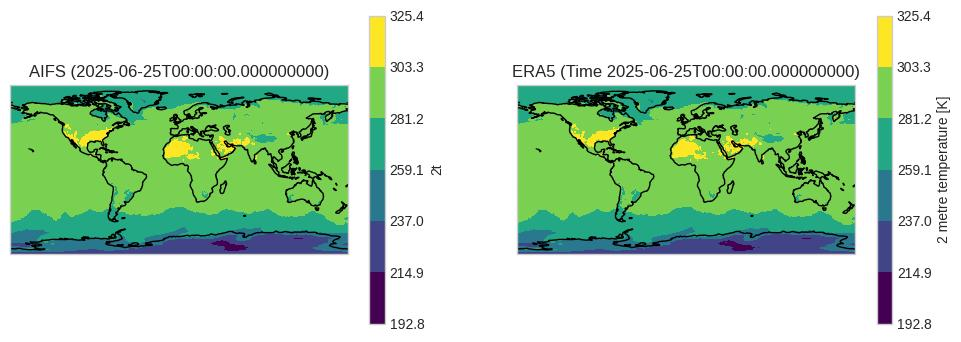

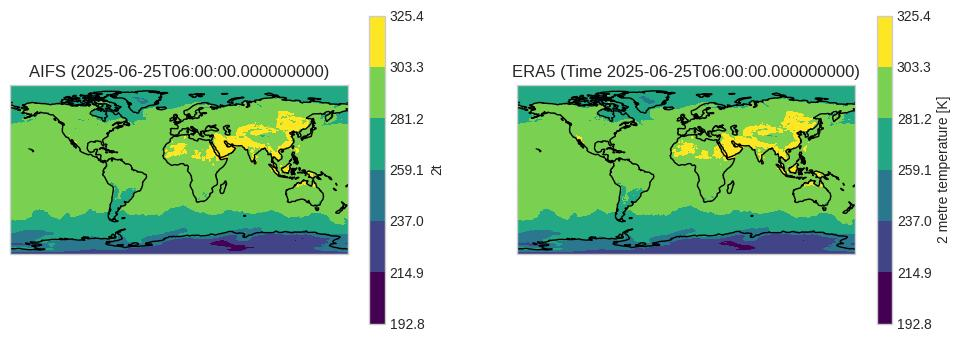

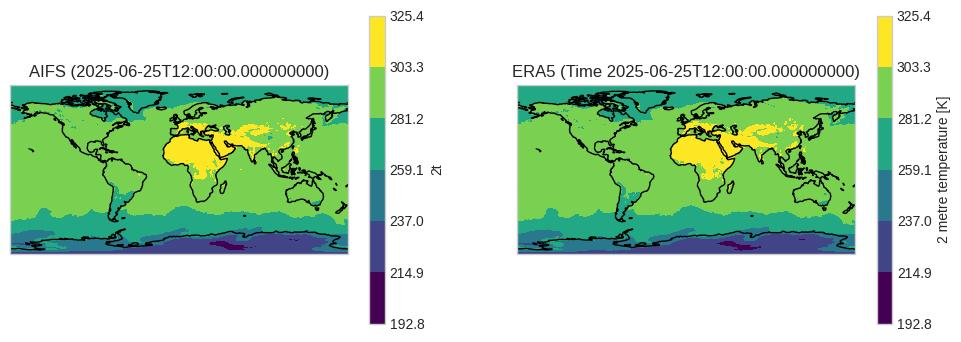

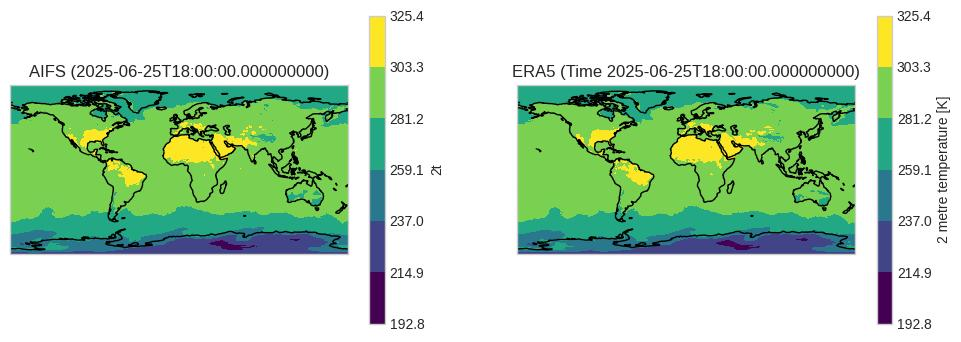

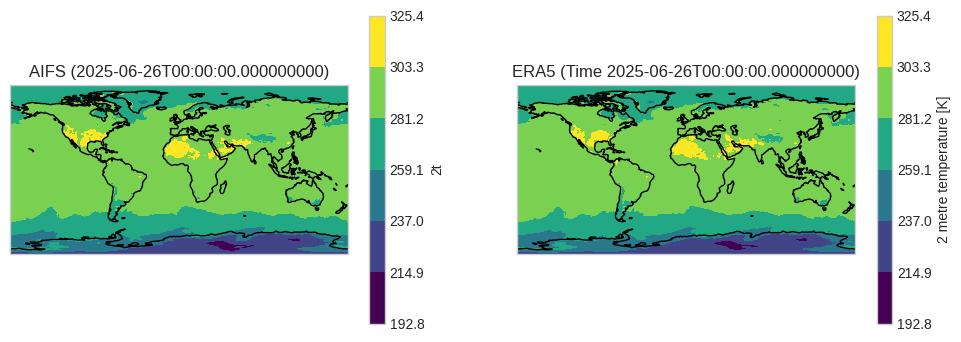

In [18]:
vmax_pred = (
    chaos_results["2025062500"]["2t"]["CRPS"].perturbed.sel(number=4)["2t"].max().item()
)
vmin_pred = (
    chaos_results["2025062500"]["2t"]["CRPS"].perturbed.sel(number=4)["2t"].min().item()
)

vmax_era5 = era5_202506_07["t2m"].max().item()
vmin_era5 = era5_202506_07["t2m"].min().item()

vmax = max(vmax_pred, vmax_era5)
vmin = min(vmin_pred, vmin_era5)

aifs_valid_times = (
    chaos_results["2025062500"]["2t"]["CRPS"].perturbed.sel(number=4).valid_time.values
)
era5_times = era5_202506_07.time.values

for i in range(5):
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 4), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    chaos_results["2025062500"]["2t"]["CRPS"].perturbed.sel(number=4).isel(step=i)[
        "2t"
    ].plot.contourf(ax=ax1, vmin=vmin, vmax=vmax)
    ax1.coastlines()
    ax1.set_title(f"AIFS ({aifs_valid_times[i]})")

    era5_202506_07.isel(time=i)["t2m"].plot.contourf(ax=ax2, vmin=vmin, vmax=vmax)
    ax2.coastlines()
    ax2.set_title(f"ERA5 (Time {era5_times[i]})")

    plt.show()

### Maps as gif

In [ ]:
chaos_results["2025062500"]["z_500"]["CRPS"].plot_nice_looking_animation(
    slice(-80, 80),
    slice(-170, 170),
    filename="CRPS_z_500_0.gif",
    cmap=ncp.pal("Lithium"),
    speed=200,
)
chaos_results["2025062500"]["z_500"]["CRPS"].plot_nice_looking_animation(
    slice(-80, 80),
    slice(-170, 170),
    filename="CRPS_z_500_4.gif",
    cmap=ncp.pal("Lithium"),
    speed=200,
    member=4,
)
chaos_results["2025062500"]["z_500"]["CRPS"].plot_nice_looking_animation(
    france_centered_latitude_bnd,
    france_centered_longitude_bnd,
    filename="CRPS_z_500_0_zoom.gif",
    cmap=ncp.pal("Lithium"),
    speed=200,
)
chaos_results["2025062500"]["z_500"]["CRPS"].plot_nice_looking_animation(
    france_centered_latitude_bnd,
    france_centered_longitude_bnd,
    filename="CRPS_z_500_4_zoom.gif",
    cmap=ncp.pal("Lithium"),
    speed=200,
    member=4,
)

## Tests spatially correlated noise

In [ ]:
for i in range(10):
    field = (
        datasets_results["2025062500"]["2t"]["EDA"].sel(number=0).isel(step=0)["2t"]
        - datasets_results["2025062500"]["2t"]["EDA"].sel(number=i).isel(step=0)["2t"]
    )
    field.plot()
    plt.show()

In [ ]:
def _generate_brownian_noise(shape, reddening=2, scale=0.5):
    """Utility to produce brownian noise using FFT (Bourke 1997)"""
    noise = np.random.normal(loc=0.0, scale=scale, size=shape)
    x_white = np.fft.rfft2(noise)

    S = (np.abs(np.fft.fftfreq(shape[-2]).reshape(-1, 1)) ** reddening) + (
        np.fft.rfftfreq(shape[-1]) ** reddening
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        S = 1.0 / S
    S[..., 0, 0] = 0.0
    S = S / np.sqrt(np.mean(S**2))

    x_shaped = x_white * S
    noise_shaped = np.fft.irfft2(x_shaped, s=(shape[-2], shape[-1]))

    return noise_shaped

In [ ]:
plt.imshow(
    _generate_brownian_noise((721, 1440), reddening=1.6, scale=0.33),
    cmap=ncp.pal("Cobalt"),
)
plt.colorbar()
plt.show()